✅ [%store] df recuperado: 1,000 × 16



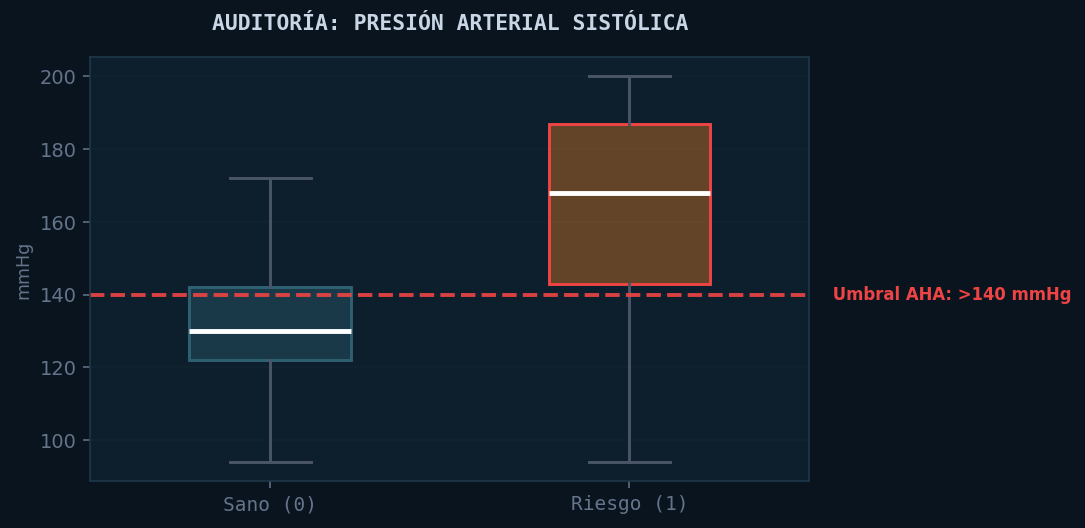
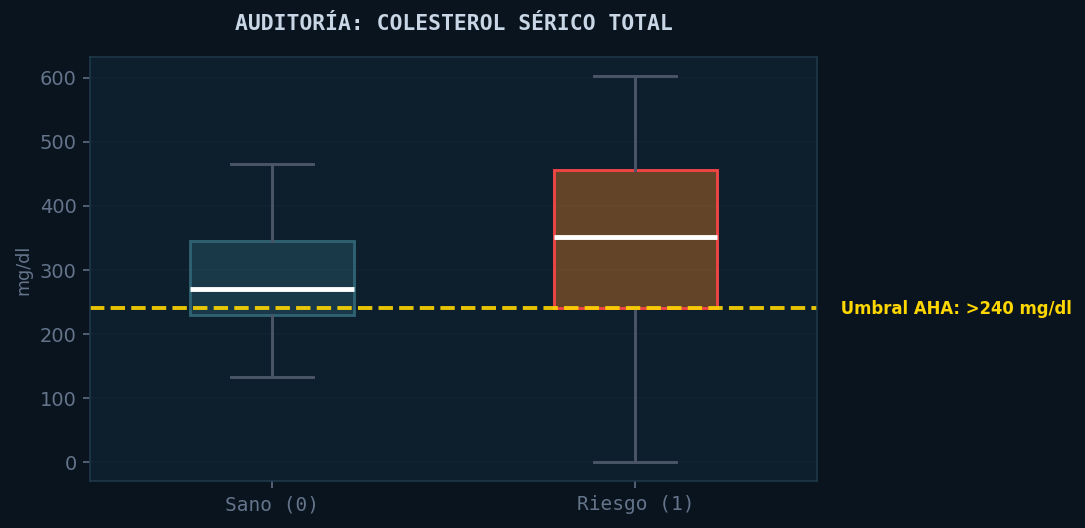
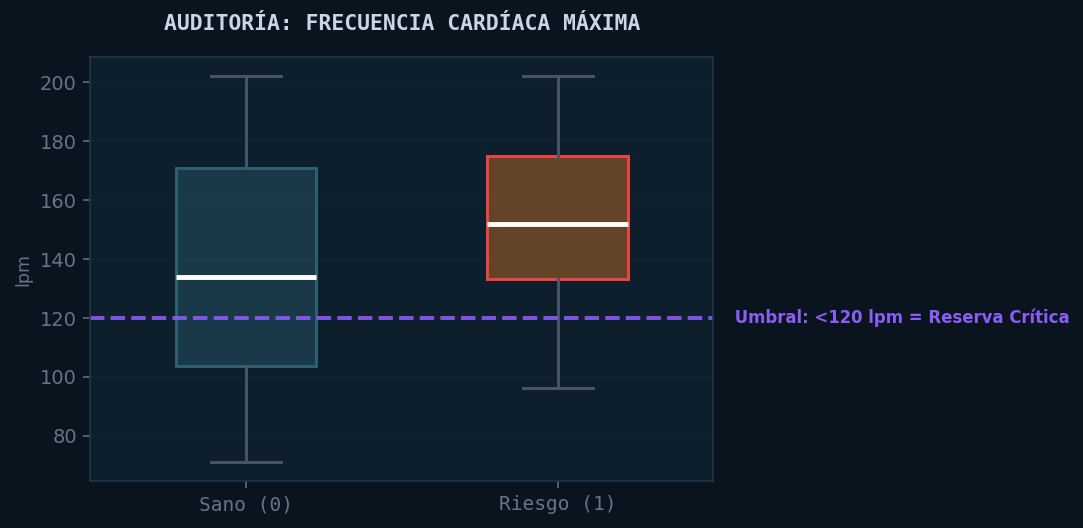
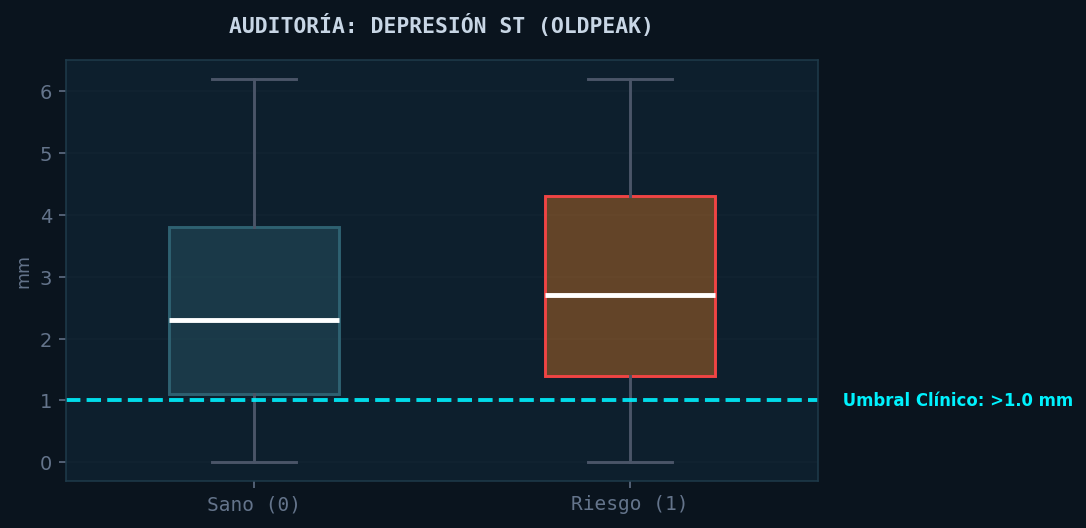

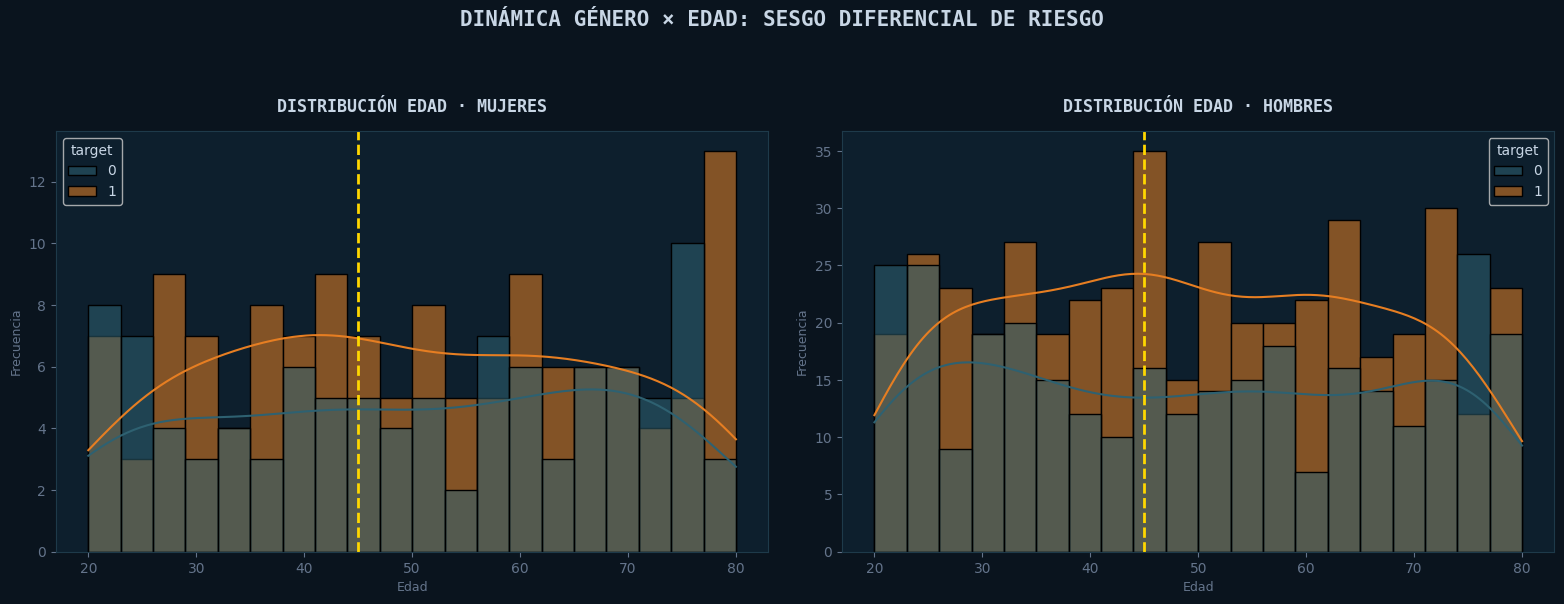

Métrica de Control,Mujeres,Hombres,Rango Referencia
Prevalencia de Riesgo (%),56.6%,58.4%,< 10% (pop. general)
Edad Media de Pacientes,50.0 años,49.0 años,—
Casos Asintomáticos (%),11.3%,5.4%,< 5% (esperado)
Presión Media (mmHg),156 mmHg,151 mmHg,< 120 mmHg (óptima)
Colesterol Medio (mg/dl),340 mg/dl,303 mg/dl,< 200 mg/dl (AHA)
FCmáx Media (lpm),141 lpm,147 lpm,≥ 220−edad lpm
"Daño Multivaso (≥2 vasos, %)",31.2%,57.5%,0% (sin enfermedad)
Predictor Maestro (Spearman),slope r=0.81,slope r=0.81,Spearman r > 0.3 = relevante


✅ Referencias bibliográficas renderizadas — 8 fuentes · 2023–2026


In [ ]:
# =============================================================================
#  FASE 2 — DATA UNDERSTANDING  ·  V5.0  ·  ARCHIVO COMPLETO
#  IBM Data Science Portfolio · CRISP-DM Methodology
# =============================================================================
#  7 CELDAS COPIABLES INDEPENDIENTES EN GOOGLE COLAB
#  Novedad V5.0: gráficas interactivas HTML/JS · Spearman · BUG-02 corregido
# =============================================================================


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 1 — SETUP · CARGA ROBUSTA · MÉTRICAS GLOBALES                       ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import base64, io, re, json
from scipy import stats
from IPython.display import HTML, display, clear_output
from IPython.utils import capture

# ─── RUTAS ────────────────────────────────────────────────────────────────────
URL_AUTOR  = "https://github.com/juanjararPYBM/ibm-data-science-portfolio"
URL_INDEX  = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/Master_Index.ipynb"
URL_KAGGLE = "https://www.kaggle.com/datasets/jocelyndumlao/cardiovascular-disease-dataset"
URL_F1     = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/cardiorisk/Fase1_Business_Understanding.ipynb"
URL_F3     = "https://colab.research.google.com/github/juanjararPYBM/ibm-data-science-portfolio/blob/main/proyecto_medico/cardiorisk/Fase3_Data_Preparation.ipynb"

# ─── PALETA ───────────────────────────────────────────────────────────────────
C_SANO   = "#2e6171"
C_RIESGO = "#e67e22"
C_GREEN  = "#00ff88"
C_CYAN   = "#00f2fe"
C_VIOLET = "#8b5cf6"
C_RED    = "#ff4444"
C_YELLOW = "#ffd700"
paleta_fix  = {0: C_SANO,   1: C_RIESGO}
paleta_dual = [C_SANO, C_RIESGO]

KAGGLE_DATASET = "jocelyndumlao/cardiovascular-disease-dataset"

# ─── CARGA ROBUSTA: %store → kagglehub → RuntimeError ────────────────────────
def cargar_datos():
    try:
        get_ipython().run_line_magic('store', '-r df')
        _df = get_ipython().user_ns.get('df')
        if isinstance(_df, pd.DataFrame) and len(_df) > 0:
            print(f"✅ [%store] df recuperado: {_df.shape[0]:,} × {_df.shape[1]}")
            return _df
    except Exception:
        print("⚠️  [%store] No disponible — intentando kagglehub...")
    try:
        import kagglehub, os, glob
        print("📦 [kagglehub] Descargando dataset...")
        path      = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
        if not csv_files:
            raise FileNotFoundError(f"No CSV encontrado en {path}")
        _df = pd.read_csv(csv_files[0])
        _df.columns = [c.strip().replace(' ', '_') for c in _df.columns]
        get_ipython().user_ns['df'] = _df
        try:
            get_ipython().run_line_magic('store', 'df')
        except Exception:
            pass
        print(f"✅ [kagglehub] {_df.shape[0]:,} × {_df.shape[1]}")
        return _df
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "kagglehub", "-q"])
        import kagglehub, os, glob
        path      = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
        _df       = pd.read_csv(csv_files[0])
        _df.columns = [c.strip().replace(' ', '_') for c in _df.columns]
        get_ipython().user_ns['df'] = _df
        print(f"✅ [kagglehub+install] {_df.shape[0]:,} × {_df.shape[1]}")
        return _df
    except Exception as e:
        print(f"❌ [kagglehub] {e}")
    raise RuntimeError(
        "\n❌ No se pudo cargar df.\n"
        "   (A) Ejecuta la celda de carga de Fase 1\n"
        "   (B) Sube manualmente 'cardiovascular_disease_dataset.csv'\n"
        "   (C) Configura credenciales Kaggle API en /root/.kaggle/kaggle.json"
    )

def resolver_columnas(df):
    _canonical = {
        'patientid':'patientid','age':'age','gender':'gender',
        'chestpain':'chestpain','restingbp':'restingBP',
        'serumcholestrol':'serumcholestrol','fastingbloodsugar':'fastingbloodsugar',
        'restingrelectro':'restingrelectro','maxheartrate':'maxheartrate',
        'exerciseangia':'exerciseangia','oldpeak':'oldpeak',
        'slope':'slope','noofmajorvessels':'noofmajorvessels','target':'target'
    }
    renames = {c: _canonical[c.lower()] for c in df.columns
               if c.lower() in _canonical and _canonical[c.lower()] != c}
    if renames:
        df = df.rename(columns=renames)
        print(f"   ↳ Columnas normalizadas: {renames}")
    return df

def enriquecer_columnas(df):
    if 'gender_label' not in df.columns:
        df['gender_label'] = df['gender'].map({0: 'Mujeres', 1: 'Hombres'})
    if 'age_group' not in df.columns:
        df['age_group'] = pd.cut(df['age'], bins=[19, 44, 54, 64, 80],
                                 labels=['<45', '45-54', '55-64', '>65'])
    return df

# ─── EJECUTAR CARGA ───────────────────────────────────────────────────────────
df = cargar_datos()
df = resolver_columnas(df)
df = enriquecer_columnas(df)

# ─── MÉTRICAS GLOBALES ────────────────────────────────────────────────────────
COLS_ESTUDIO  = ['age','restingBP','serumcholestrol','maxheartrate',
                 'oldpeak','noofmajorvessels','chestpain','slope','target']
CORR_SPEARMAN = df[COLS_ESTUDIO].corr(method='spearman').round(3)
REAL_CORR     = round(CORR_SPEARMAN.loc['slope', 'target'], 2)
PCT_RIESGO    = round((df['target'].value_counts(normalize=True) * 100)[1], 1)
TOP_CORR_VAR  = CORR_SPEARMAN['target'].abs().drop('target').idxmax()
TOP_CORR_VAL  = round(CORR_SPEARMAN['target'][TOP_CORR_VAR], 2)

# métricas en silencio — visibles en el header visual de Celda 2


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 2 — HEADER VISUAL · DICCIONARIO · VALIDACIÓN DE DATOS               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

assert 'REAL_CORR' in globals(), "❌ Ejecuta la Celda 1 primero"

# ─── CSS MAESTRO V5.0 ─────────────────────────────────────────────────────────
F2_STYLES = """
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600;700;800&family=Inter:wght@300;400;600&display=swap');
:root {
  --f2-violet:#8b5cf6; --arctic:#f8fafc; --cyan:#00f2fe; --red:#ff4444;
  --green:#00ff88;     --dark-bg:#0a141e; --orange:#ffd700;
  --surface:#0d1f2d;   --border:rgba(255,255,255,0.07); --muted:#4a5568; --text:#c8d6e5;
}
*,*::before,*::after{box-sizing:border-box}
.f2-wrap{background:var(--dark-bg);border-radius:20px;padding:40px 44px;max-width:980px;
  margin:0 auto;box-shadow:0 0 0 1px var(--border),0 24px 80px rgba(0,0,0,.7);font-family:'Inter',sans-serif}
.rev-buttons{display:flex;gap:10px;flex-wrap:wrap;margin-bottom:28px}
.rev-btn{padding:8px 18px;border-radius:8px;font-family:'JetBrains Mono',monospace;font-size:.72em;
  font-weight:700;letter-spacing:1px;cursor:pointer;text-decoration:none;
  display:inline-flex;align-items:center;gap:7px;border:1px solid;transition:all .25s}
.rev-btn:hover{transform:translateY(-2px);box-shadow:0 6px 20px rgba(0,0,0,.4)}
.btn-f1 {color:#94a3b8;border-color:rgba(148,163,184,.3);background:rgba(148,163,184,.07)}
.btn-idx{color:#00f2fe;border-color:rgba(0,242,254,.3);background:rgba(0,242,254,.07)}
.btn-kgl{color:#f59e0b;border-color:rgba(245,158,11,.3);background:rgba(245,158,11,.07)}
.btn-f3 {color:#00ff88;border-color:rgba(0,255,136,.3);background:rgba(0,255,136,.07)}
.idx-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin-bottom:28px}
.idx-card{background:#0d1f2d;border:1px solid rgba(255,255,255,0.07);border-radius:10px;
  padding:12px 14px;cursor:pointer;transition:all .22s}
.idx-card:hover{border-color:rgba(139,92,246,.4);background:rgba(139,92,246,.08);transform:translateY(-2px)}
.idx-num{font-family:'JetBrains Mono',monospace;font-size:.58em;color:#4a5568;
  letter-spacing:2px;text-transform:uppercase;margin-bottom:5px}
.idx-label{color:#f8fafc;font-size:.78em;font-weight:600;line-height:1.3}
.idx-card.active{border-color:rgba(139,92,246,.5)!important;background:rgba(139,92,246,.12)!important}
.idx-card.active .idx-num{color:#8b5cf6}
.idx-card.active .idx-label{color:#a78bfa}
.ph-row{border-radius:12px;padding:14px 20px;margin-bottom:10px;border-left:4px solid;
  font-family:'JetBrains Mono',monospace}
.ph-green {background:rgba(0,255,136,.05);border-color:#00ff88}
.ph-violet{background:rgba(139,92,246,.05);border-color:#8b5cf6}
.ph-red   {background:rgba(255,68,68,.05);border-color:#ef4444}
.ph-cyan  {background:rgba(0,242,254,.05);border-color:#00f2fe}
.ph-label{font-size:.6em;letter-spacing:3px;color:#4a5568;text-transform:uppercase;margin-bottom:5px}
.ph-body {font-size:.82em;color:#f8fafc;line-height:1.6}
.sec-div{font-family:'JetBrains Mono',monospace;font-size:.65em;letter-spacing:3px;
  text-transform:uppercase;color:#4a5568;border-bottom:1px solid var(--border);
  padding-bottom:8px;margin:28px 0 16px}
.audit-section{display:flex;flex-direction:column;gap:6px}
.audit-row{display:flex;justify-content:space-between;align-items:center;
  background:#0d1f2d;border:1px solid rgba(255,255,255,.07);border-radius:8px;
  padding:9px 16px;font-family:'JetBrains Mono',monospace;font-size:.75em}
.a-ok{color:#00ff88;font-weight:700}
.a-warn{color:#f59e0b;font-weight:700}
.a-val{color:#f8fafc;font-weight:700}
.nul-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:6px;margin-top:8px}
.nul-cell{background:#0d1f2d;border:1px solid rgba(255,255,255,.07);border-radius:7px;padding:8px 12px;
  font-family:'JetBrains Mono',monospace}
.nul-var{font-size:.65em;color:#4a5568;text-transform:uppercase;letter-spacing:1px;margin-bottom:3px}
.nul-val{font-size:.85em;font-weight:700}
.nul-ok {color:#00ff88}
.nul-bad{color:#ef4444}
.bal-grid{display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-top:10px}
.bal-card{border-radius:8px;padding:12px 16px;text-align:center}
.bal-pct{font-family:'JetBrains Mono',monospace;font-size:1.4em;font-weight:800}
.bal-lbl{font-family:'JetBrains Mono',monospace;font-size:.62em;color:#4a5568;
  text-transform:uppercase;letter-spacing:2px;margin-top:3px}
.insight-banner{background:rgba(0,0,0,.35);border:1px solid rgba(139,92,246,.25);
  border-left:4px solid var(--f2-violet);border-radius:0 12px 12px 0;
  padding:16px 20px;margin:16px 0;max-width:980px}
.insight-banner h4{color:#f8fafc;font-family:'JetBrains Mono',monospace;
  font-size:.82em;margin-bottom:7px;letter-spacing:.5px}
.insight-banner p{color:#f8fafc;font-size:.83em;line-height:1.7;opacity:.88}
.insight-banner.warn{border-color:rgba(245,158,11,.3);border-left-color:#f59e0b}
.insight-banner.info{border-color:rgba(0,242,254,.2);border-left-color:#00f2fe}
.ref-tag{display:inline-flex;align-items:center;font-family:'JetBrains Mono',monospace;
  font-size:.62em;font-weight:700;padding:2px 8px;border-radius:10px;cursor:pointer;
  background:rgba(139,92,246,.12);color:#8b5cf6;border:1px solid rgba(139,92,246,.25);
  transition:all .2s;text-decoration:none;margin-left:4px}
.ref-tag:hover{background:rgba(139,92,246,.22);transform:scale(1.05)}
.ref-tag.g{background:rgba(0,255,136,.1);color:#00ff88;border-color:rgba(0,255,136,.25)}
.ref-tag.c{background:rgba(0,242,254,.1);color:#00f2fe;border-color:rgba(0,242,254,.2)}
.ref-tag.r{background:rgba(255,68,68,.1);color:#ef4444;border-color:rgba(255,68,68,.25)}
table.glass-df{width:100%;border-collapse:collapse;font-family:'JetBrains Mono',monospace;font-size:.72em;min-width:1600px}
table.glass-df thead th{background:#000;color:#f8fafc;
  padding:14px 22px;text-align:center;letter-spacing:.5px;font-size:.7em;text-transform:uppercase;
  white-space:nowrap;border-bottom:1px solid rgba(139,92,246,.3);font-weight:800}
table.glass-df tbody tr{border-bottom:1px solid rgba(255,255,255,.03)}
table.glass-df tbody tr:hover{background:rgba(255,255,255,.03)}
table.glass-df tbody td{padding:10px 22px;color:#f8fafc;text-align:center;white-space:nowrap}
table.glass-df tbody th{background:rgba(0,0,0,.9);color:#94a3b8;font-weight:700;padding:10px 18px;
  font-size:.78em;border-right:1.5px solid #8b5cf6;position:sticky;left:0;z-index:5;white-space:nowrap}
/* DARK CARDS CONCLUSIONES */
.dark-card-grid{display:grid;grid-template-columns:repeat(2,1fr);gap:14px;margin-bottom:20px}
.dark-card{background:#0d1f2d;border:1px solid rgba(255,255,255,.07);border-radius:14px;
  padding:20px 22px;position:relative;overflow:hidden}
.dark-card::before{content:'';position:absolute;top:0;left:0;right:0;height:3px}
.dc-green::before{background:linear-gradient(90deg,var(--green),var(--cyan))}
.dc-violet::before{background:linear-gradient(90deg,var(--f2-violet),#c084fc)}
.dc-red::before{background:linear-gradient(90deg,var(--red),var(--orange))}
.dc-cyan::before{background:linear-gradient(90deg,var(--cyan),#38bdf8)}
.dark-card .dc-icon{font-size:1.6em;margin-bottom:10px}
.dark-card .dc-title{font-family:'JetBrains Mono',monospace;font-size:.72em;
  letter-spacing:2px;text-transform:uppercase;color:#4a5568;margin-bottom:8px}
.dark-card .dc-val{font-family:'JetBrains Mono',monospace;font-size:1.8em;
  font-weight:800;line-height:1.1;margin-bottom:6px}
.dark-card .dc-desc{font-size:.78em;color:#f8fafc;line-height:1.6;opacity:.85}
/* REFS SECTION */
.ref-entry{background:#0d1f2d;border:1px solid rgba(255,255,255,.07);border-radius:12px;
  padding:18px 22px;margin-bottom:10px}
.ref-num{display:inline-block;font-family:'JetBrains Mono',monospace;font-size:.65em;
  font-weight:800;padding:2px 8px;border-radius:6px;background:rgba(139,92,246,.15);
  color:#8b5cf6;margin-bottom:8px}
.ref-title{color:#f8fafc;font-weight:600;font-size:.88em;margin-bottom:5px}
.ref-meta{font-family:'JetBrains Mono',monospace;font-size:.68em;color:#4a5568;margin-bottom:6px}
.ref-finding{font-size:.8em;color:#f8fafc;line-height:1.6;
  border-left:3px solid rgba(139,92,246,.3);padding-left:10px;margin-top:6px;opacity:.9}
.ref-doi{font-family:'JetBrains Mono',monospace;font-size:.63em;color:#00f2fe;
  text-decoration:none;display:inline-flex;align-items:center;gap:4px;margin-top:6px}
.ref-doi:hover{text-decoration:underline}
/* CHART CONTAINERS */
.chart-wrap{background:#0d1f2d;border:1px solid rgba(255,255,255,.07);border-radius:14px;
  padding:20px;margin:16px 0;position:relative}
.chart-title{font-family:'JetBrains Mono',monospace;font-size:.65em;letter-spacing:2px;
  text-transform:uppercase;color:#4a5568;margin-bottom:14px}
</style>
<script src="https://cdnjs.cloudflare.com/ajax/libs/gsap/3.12.2/gsap.min.js"></script>
<script src="https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js"></script>
"""

# ─── DICCIONARIO CLÍNICO V.10.3 ───────────────────────────────────────────────
DICT_V103 = r"""<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@400;600;700;800&family=Inter:wght@300;400;600&display=swap');
.dict-container{background:#0a141e;border-radius:16px;padding:28px 32px;max-width:980px;margin:0 auto;box-shadow:0 0 0 1px rgba(255,255,255,0.07),0 20px 60px rgba(0,0,0,0.7);font-family:'Inter',sans-serif}
.dict-header{display:flex;align-items:center;gap:16px;margin-bottom:20px}
.dict-badge{font-family:'JetBrains Mono',monospace;font-size:.62em;font-weight:700;letter-spacing:3px;padding:4px 12px;border-radius:20px;background:rgba(139,92,246,0.12);color:#8b5cf6;border:1px solid rgba(139,92,246,0.25);text-transform:uppercase}
.dict-tier-header{font-family:'JetBrains Mono',monospace;font-size:.6em;letter-spacing:3px;text-transform:uppercase;padding:6px 14px;border-radius:6px;margin:14px 0 8px;display:inline-block}
.dict-grid{display:grid;grid-template-columns:repeat(2,1fr);gap:8px;margin-bottom:4px}
.dict-entry{background:#0d1f2d;border:1px solid rgba(255,255,255,0.06);border-radius:10px;padding:12px 14px;position:relative;transition:all .25s;cursor:default;overflow:hidden}
.dict-entry::before{content:'';position:absolute;top:0;left:0;right:0;height:2px;opacity:.7}
.dict-entry:hover{transform:translateY(-2px);box-shadow:0 0 0 1px var(--dh-color,rgba(139,92,246,.4)),0 0 18px var(--dh-glow,rgba(139,92,246,.12))}
.dict-top{display:grid;grid-template-columns:auto 1fr;align-items:start;gap:10px;margin-bottom:6px}
.dict-icon{font-size:1.1em;line-height:1;margin-top:2px}
.dict-var{font-family:'JetBrains Mono',monospace;font-size:.72em;font-weight:700;letter-spacing:.5px;margin-bottom:2px}
.dict-label{color:#94a3b8;font-size:.75em;line-height:1.5}
.dict-bottom{display:flex;justify-content:space-between;align-items:flex-end;margin-top:8px;padding-top:6px;border-top:1px solid rgba(255,255,255,.05)}
.dict-tier{display:inline-flex;align-items:center;gap:4px;font-family:'JetBrains Mono',monospace;font-size:.58em;font-weight:700;letter-spacing:1.5px;padding:2px 7px;border-radius:4px;text-transform:uppercase}
.dict-ranges{text-align:right}
.dict-range-study{font-family:'JetBrains Mono',monospace;font-size:.6em;color:#4a5568;background:rgba(0,0,0,.3);padding:2px 7px;border-radius:5px;display:block;margin-bottom:2px}
.dict-range-normal{font-family:'JetBrains Mono',monospace;font-size:.6em;padding:2px 7px;border-radius:5px;display:block}
/* TIER 1 PREDICTOR - GOLD */
.t1-pred::before{background:linear-gradient(90deg,#ffd700,#ffe433)}
.t1-pred{--dh-color:rgba(245,158,11,.5);--dh-glow:rgba(245,158,11,.15)}
.t1-pred .dict-var{color:#ffe433}
/* TIER 1 TARGET - RED */
.t1-target::before{background:linear-gradient(90deg,#ef4444,#ff6b6b)}
.t1-target{--dh-color:rgba(239,68,68,.5);--dh-glow:rgba(239,68,68,.15)}
.t1-target .dict-var{color:#ff6b6b}
/* TIER 1 SHAP - CYAN */
.t1-shap::before{background:linear-gradient(90deg,#00f2fe,#38bdf8)}
.t1-shap{--dh-color:rgba(0,242,254,.4);--dh-glow:rgba(0,242,254,.12)}
.t1-shap .dict-var{color:#00f2fe}
/* TIER 2 - VIOLET */
.t2::before{background:linear-gradient(90deg,#8b5cf6,#c084fc)}
.t2{--dh-color:rgba(139,92,246,.4);--dh-glow:rgba(139,92,246,.12)}
.t2 .dict-var{color:#c084fc}
/* TIER 3 - MUTED */
.t3::before{background:rgba(100,116,139,.4)}
.t3{--dh-color:rgba(100,116,139,.3);--dh-glow:rgba(100,116,139,.08)}
.t3 .dict-var{color:#94a3b8}
.tier-1-gold{background:rgba(245,158,11,.12);color:#ffe433}
.tier-1-cyan{background:rgba(0,242,254,.1);color:#00f2fe}
.tier-1-red{background:rgba(239,68,68,.12);color:#ef4444}
.tier-2-v{background:rgba(139,92,246,.12);color:#8b5cf6}
.tier-3-m{background:rgba(100,116,139,.15);color:#64748b}
.normal-ref{color:#00ff88;background:rgba(0,255,136,.08)}
.normal-na{color:#4a5568;background:rgba(0,0,0,.2)}
</style>
<div class="dict-container">
  <div class="dict-header">
    <span class="dict-badge">V.10.3</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.7em;color:#64748b;letter-spacing:1px">DICCIONARIO CLÍNICO · 14 VARIABLES · Agrupado por Nivel Predictivo</span>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;letter-spacing:3px;color:#ffe433;text-transform:uppercase;margin-bottom:6px">★ PREDICTOR MAESTRO</div>
  <div class="dict-grid" style="grid-template-columns:1fr">
    <div class="dict-entry t1-pred">
      <div class="dict-top"><div class="dict-icon">📐</div><div>
        <div class="dict-var">slope</div>
        <div class="dict-label">Pendiente del segmento ST en ejercicio máximo. <b>0=Ascendente</b> (sano) · <b>1=Plana</b> · <b>2=Descendente</b> = isquemia obstructiva severa.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-gold">★ PREDICTOR #1 · Spearman r=0.81</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–2 (categórica ordinal)</span>
          <span class="dict-range-normal normal-ref">Normal: Ascendente (0) en esfuerzo</span>
        </div>
      </div>
    </div>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;letter-spacing:3px;color:#00f2fe;text-transform:uppercase;margin:14px 0 6px">◈ TIER 1 · PREDICTORES SHAP CRÍTICOS</div>
  <div class="dict-grid">
    <div class="dict-entry t1-shap">
      <div class="dict-top"><div class="dict-icon">💢</div><div>
        <div class="dict-var">chestpain</div>
        <div class="dict-label">Tipo dolor pectoral. <b>0=Angina típica</b> · <b>1=Atípica</b> · <b>2=No anginal</b> · <b>3=Asintomático</b> — mayor riesgo silente.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-cyan">TIER 1 · SHAP #2</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–3</span>
          <span class="dict-range-normal normal-ref">Normal: 0 (Angina típica)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t1-shap">
      <div class="dict-top"><div class="dict-icon">❤️</div><div>
        <div class="dict-var">maxheartrate</div>
        <div class="dict-label">Frecuencia cardíaca máxima alcanzada (lpm). Fórmula ref: <b>220 − edad</b>. FCmáx reducida = menor reserva funcional.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-cyan">TIER 1 · SHAP</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 71–202 lpm</span>
          <span class="dict-range-normal normal-ref">Normal: ≥ 220−edad lpm</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t1-shap">
      <div class="dict-top"><div class="dict-icon">📉</div><div>
        <div class="dict-var">oldpeak</div>
        <div class="dict-label">Depresión del segmento ST durante ejercicio vs. reposo (mm). <b>&gt;1.0mm</b> = isquemia funcional confirmada.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-cyan">TIER 1 · SHAP</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–6.2 mm</span>
          <span class="dict-range-normal normal-ref">Normal: &lt; 1.0 mm (AHA)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t1-shap">
      <div class="dict-top"><div class="dict-icon">🫀</div><div>
        <div class="dict-var">noofmajorvessels</div>
        <div class="dict-label">Vasos coronarios principales obstruidos (fluoroscopía). <b>≥2 vasos</b> = daño estructural multivaso severo.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-cyan">TIER 1 · SHAP</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–3 vasos</span>
          <span class="dict-range-normal normal-ref">Normal: 0 vasos obstruidos</span>
        </div>
      </div>
    </div>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;letter-spacing:3px;color:#8b5cf6;text-transform:uppercase;margin:14px 0 6px">◆ TIER 2 · PREDICTORES MODERADOS</div>
  <div class="dict-grid">
    <div class="dict-entry t2">
      <div class="dict-top"><div class="dict-icon">📈</div><div>
        <div class="dict-var">restingrelectro</div>
        <div class="dict-label">ECG en reposo. <b>0=Normal</b> · <b>1=Anormalidad ST-T</b> (isquemia previa) · <b>2=Hipertrofia ventricular</b> izquierda.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-2-v">TIER 2</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–2</span>
          <span class="dict-range-normal normal-ref">Normal: 0 (sin anomalías)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t2">
      <div class="dict-top"><div class="dict-icon">🏃</div><div>
        <div class="dict-var">exerciseangia</div>
        <div class="dict-label">Angina inducida por ejercicio. <b>1=Sí</b> = demanda supera suministro coronario en esfuerzo.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-2-v">TIER 2</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–1 (binaria)</span>
          <span class="dict-range-normal normal-ref">Normal: 0 (sin angina)</span>
        </div>
      </div>
    </div>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;letter-spacing:3px;color:#64748b;text-transform:uppercase;margin:14px 0 6px">▪ TIER 3 · VARIABLES CONTEXTUALES</div>
  <div class="dict-grid">
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">📅</div><div>
        <div class="dict-var">age</div>
        <div class="dict-label">Edad del paciente en años. Umbral inflexión epidemiológica: <b>45 años</b>.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">TIER 3</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 29–77 años</span>
          <span class="dict-range-normal normal-na">Riesgo ↑ a partir 45 años</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">⚧</div><div>
        <div class="dict-var">gender</div>
        <div class="dict-label">Sexo biológico. <b>0=Mujer</b> · <b>1=Hombre</b>. Diferencia perfil de riesgo silente.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">TIER 3</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–1 (binaria)</span>
          <span class="dict-range-normal normal-na">Ambos con riesgo diferencial</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">🩺</div><div>
        <div class="dict-var">restingBP</div>
        <div class="dict-label">Presión arterial sistólica en reposo (mmHg). <b>&gt;140</b> = Hipertensión St.2 (AHA).</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">TIER 3</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 94–200 mmHg</span>
          <span class="dict-range-normal normal-ref">Normal: &lt; 120/80 mmHg (AHA)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">🧪</div><div>
        <div class="dict-var">serumcholestrol</div>
        <div class="dict-label">Colesterol sérico total (mg/dl). <b>&gt;240</b> = Riesgo elevado (AHA). Outliers &gt;400 en riesgo.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">TIER 3</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 85–603 mg/dl</span>
          <span class="dict-range-normal normal-ref">Deseable: &lt; 200 mg/dl (AHA)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">🍬</div><div>
        <div class="dict-var">fastingbloodsugar</div>
        <div class="dict-label">Glucemia en ayunas. <b>0 = ≤120 mg/dl</b> · <b>1 = &gt;120 mg/dl</b> (diabetes metabólica).</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">TIER 3</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–1 (binaria)</span>
          <span class="dict-range-normal normal-ref">Normal: &lt; 100 mg/dl (ADA)</span>
        </div>
      </div>
    </div>
    <div class="dict-entry t3">
      <div class="dict-top"><div class="dict-icon">🆔</div><div>
        <div class="dict-var">patientid</div>
        <div class="dict-label">Identificador único del paciente. Variable de índice, excluida del modelo predictivo.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-3-m">ID</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: entero</span>
          <span class="dict-range-normal normal-na">N/A — identificador</span>
        </div>
      </div>
    </div>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;letter-spacing:3px;color:#ef4444;text-transform:uppercase;margin:14px 0 6px">◎ TARGET · VARIABLE OBJETIVO</div>
  <div class="dict-grid" style="grid-template-columns:1fr">
    <div class="dict-entry t1-target">
      <div class="dict-top"><div class="dict-icon">🎯</div><div>
        <div class="dict-var">target</div>
        <div class="dict-label">Variable objetivo del modelo. <b>0 = Bajo riesgo cardíaco</b> · <b>1 = Alto riesgo cardíaco</b>. Balance: 42% sano / 58% riesgo.</div>
      </div></div>
      <div class="dict-bottom">
        <span class="dict-tier tier-1-red">TARGET · BINARIA</span>
        <div class="dict-ranges">
          <span class="dict-range-study">Dataset: 0–1</span>
          <span class="dict-range-normal normal-ref">Objetivo: 0 (sin riesgo)</span>
        </div>
      </div>
    </div>
  </div>
  <div style="font-family:'JetBrains Mono',monospace;font-size:.58em;color:#4a5568;margin-top:12px;padding-top:8px;border-top:1px solid rgba(255,255,255,.05)">
    ◈ Rangos verdes = valores hallados en el estudio (dataset Kaggle CD)
    · Rangos de referencia = estándares AHA/ACC/ADA
  </div>

<script>
(function() {
  // Add hover glow effects to all dict-entry cards
  document.querySelectorAll('.dict-entry').forEach(function(card) {
    card.addEventListener('mouseenter', function() {
      // Determine tier from class
      var isTier1Gold   = card.classList.contains('t1-pred');
      var isTier1Target = card.classList.contains('t1-target');
      var isTier1Cyan   = card.classList.contains('t1-shap');
      var isTier2       = card.classList.contains('t2');
      var glowColor = isTier1Gold ? 'rgba(255,228,51,.25)' :
                      isTier1Target ? 'rgba(239,68,68,.2)' :
                      isTier1Cyan  ? 'rgba(0,242,254,.2)' :
                      isTier2      ? 'rgba(139,92,246,.2)' :
                                     'rgba(100,116,139,.15)';
      var borderColor = isTier1Gold ? '#ffe433' :
                        isTier1Target ? '#ef4444' :
                        isTier1Cyan  ? '#00f2fe' :
                        isTier2      ? '#8b5cf6' : '#4a5568';
      card.style.boxShadow = '0 0 0 1.5px ' + borderColor + ', 0 0 24px ' + glowColor + ', 0 8px 32px rgba(0,0,0,.4)';
      card.style.background = isTier1Gold ? 'rgba(255,228,51,.08)' :
                               isTier1Target ? 'rgba(239,68,68,.08)' :
                               isTier1Cyan  ? 'rgba(0,242,254,.06)' :
                               isTier2      ? 'rgba(139,92,246,.08)' : 'rgba(255,255,255,.03)';
      card.style.transform   = 'translateY(-3px)';
      card.style.transition  = 'all .25s cubic-bezier(.16,.84,.44,1)';
      // Glow on the tier badge
      var badge = card.querySelector('.dict-tier');
      if (badge) badge.style.filter = 'brightness(1.5)';
      // Glow on the range labels
      card.querySelectorAll('.dict-range-study, .dict-range-normal').forEach(function(r) {
        r.style.filter = 'brightness(1.4)';
      });
    });
    card.addEventListener('mouseleave', function() {
      card.style.boxShadow  = '';
      card.style.background = '';
      card.style.transform  = '';
      var badge = card.querySelector('.dict-tier');
      if (badge) badge.style.filter = '';
      card.querySelectorAll('.dict-range-study, .dict-range-normal').forEach(function(r) {
        r.style.filter = '';
      });
    });
  });
})();
</script>
</div>"""


# ─── UTILIDADES ───────────────────────────────────────────────────────────────
def render_v40(df_input, title_text, step_id='F2.2'):
    """Full V4.0 table with crosshair hover effect — replaces render_v50"""
    import re as _re
    html_raw = df_input.to_html(classes='glass-df')
    u_id = 'v40_' + _re.sub(r'[^a-zA-Z0-9_]', '_', step_id)
    return f"""
<div style='font-family:Inter,sans-serif;max-width:1100px;margin:0 auto 18px;
     background:#050a0f;border-radius:20px;border:1px solid rgba(139,92,246,0.15);overflow:hidden'>
  <div style='background:rgba(0,0,0,0.7);padding:18px 25px;border-bottom:1px solid rgba(139,92,246,0.1);
              display:flex;justify-content:space-between;align-items:center'>
    <span style='font-family:JetBrains Mono,monospace;color:#f8fafc;font-weight:800;
                 font-size:.75em;letter-spacing:2px'>📋 {title_text}</span>
    <span style='color:#8b5cf6;font-size:.6em;font-weight:900'>{step_id}</span>
  </div>
  <div style='overflow-x:auto;width:100%;scrollbar-width:thin;scrollbar-color:#8b5cf6 #111' id='{u_id}'>
    {html_raw}
  </div>
</div>
<script>
(function() {{
  var t = document.querySelector('#{u_id} .glass-df');
  if (!t) return;
  t.querySelectorAll('td').forEach(function(cell) {{
    cell.addEventListener('mouseenter', function() {{
      var ci = cell.cellIndex;
      t.querySelectorAll('tr').forEach(function(row) {{
        Array.from(row.cells).forEach(function(c, idx) {{
          if (idx === ci) c.style.background = 'rgba(139,92,246,0.12)';
        }});
      }});
      Array.from(cell.parentElement.cells).forEach(function(c) {{
        c.style.background = 'rgba(139,92,246,0.12)';
      }});
      cell.style.background = '#f8fafc';
      cell.style.color      = '#000';
      cell.style.fontWeight = '900';
      cell.style.boxShadow  = '0 0 20px rgba(139,92,246,0.6)';
    }});
    cell.addEventListener('mouseleave', function() {{
      t.querySelectorAll('td').forEach(function(c) {{
        c.style.background  = '';
        c.style.color       = '';
        c.style.fontWeight  = '';
        c.style.boxShadow   = '';
      }});
    }});
  }});
}})();
</script>"""

# Keep render_v50 as alias
def render_v50(df_input, title_text, step_id="F2"):
    return render_v40(df_input, title_text, step_id)


def banner_ref(titulo, mensaje, refs=None, tipo="default"):
    clase = {"warn": "warn", "info": "info"}.get(tipo, "")
    tags  = ""
    if refs:
        for r in refs:
            cls = r.get('cls', '')
            tags += (f'<a class="ref-tag {cls}" href="{r["url"]}" target="_blank">'
                     f'[{r["num"]}] {r["label"]}</a>')
    ref_block = f'<div style="margin-top:10px">{tags}</div>' if tags else ""
    display(HTML(f"""{F2_STYLES}
    <div class="insight-banner {clase}" style="max-width:980px;margin:0 auto">
      <h4>💡 {titulo}</h4>
      <p>{mensaje}</p>
      {ref_block}
    </div>"""))

def fig_to_b64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=140, bbox_inches='tight',
                facecolor='#0a141e', edgecolor='none')
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

# ─── BUILD HEADER ─────────────────────────────────────────────────────────────
def build_header_v50():
    n_reg   = f"{df.shape[0]:,}"
    n_vars  = df.shape[1]
    n_nulos = int(df.isnull().sum().sum())
    pct_1   = round((df['target'].value_counts(normalize=True) * 100).get(1, 0), 1)
    pct_0   = round(100 - pct_1, 1)

    nulos_html = ""
    for c in df.columns:
        n_col  = df[c].isnull().sum()
        cls    = "nul-ok"  if n_col == 0 else "nul-bad"
        val    = "✓ 0"     if n_col == 0 else f"⚠ {n_col}"
        nulos_html += (f'<div class="nul-cell">'
                       f'<div class="nul-var">{c}</div>'
                       f'<div class="nul-val {cls}">{val}</div>'
                       f'</div>')

    nulos_cls   = "a-ok"  if n_nulos == 0 else "a-warn"
    nulos_texto = "✓ Dataset completo — 0 nulos" if n_nulos == 0 else f"⚠ {n_nulos} nulos detectados"

    idx_items = [
        ("C1","Setup & Carga Robusta"),
        ("C2","Header · Dict · Validación"),
        ("C3","EDA Univariado"),
        ("C4","EDA Bivariado · Correlaciones"),
        ("C5","EDA Multivariado"),
        ("C6","Conclusiones · F3"),
        ("C7","Referencias Bibliográficas"),
    ]
    idx_html = ""
    for _n, _l in idx_items:
        _act  = _n == "C2"
        _bg   = "rgba(139,92,246,.15)" if _act else "#0d1f2d"
        _bdr  = "rgba(139,92,246,.55)" if _act else "rgba(255,255,255,.07)"
        _nc   = "#a78bfa"              if _act else "#4a5568"
        _lc   = "#a78bfa"             if _act else "#f8fafc"
        idx_html += (
            f'<div style="background:{_bg};border:1px solid {_bdr};border-radius:10px;' +
            f'padding:12px 14px;cursor:pointer;">' +
            f'<div style="font-family:JetBrains Mono,monospace;font-size:.58em;color:{_nc};' +
            f'letter-spacing:2px;text-transform:uppercase;margin-bottom:5px">{_n}</div>' +
            f'<div style="color:{_lc};font-size:.78em;font-weight:600;line-height:1.3">{_l}</div>' +
            '</div>'
        )

    return f"""{F2_STYLES}
<div class="f2-wrap" id="f2-header">
  <h1 style="font-family:'JetBrains Mono',monospace;font-weight:800;font-size:2.2em;
             margin:0 0 6px;line-height:1.2;color:#8b5cf6">
    Fase 2: Data Understanding</h1>
  <p style="color:#64748b;font-size:1em;margin-bottom:28px;font-weight:600;letter-spacing:.4px">
    Scientific Requirements &amp; Clinical EDA · IBM CRISP-DM · V5.0</p>

  <div class="rev-buttons">
    <a class="rev-btn btn-f1"  href="{URL_F1}"     target="_blank">← F1 Business</a>
    <a class="rev-btn btn-idx" href="{URL_INDEX}"  target="_blank">◈ Master Index</a>
    <a class="rev-btn btn-kgl" href="{URL_KAGGLE}" target="_blank">⬡ Kaggle Dataset</a>
    <a class="rev-btn btn-f3"  href="{URL_F3}"     target="_blank">F3 Preparation →</a>
  </div>

  <div class="sec-div">📋 Arquitectura V5.0 — 7 Bloques CRISP-DM</div>
  <div class="idx-grid">{idx_html}</div>

  <div class="sec-div">🔬 Conceptos y Requerimientos Clínicos</div>

  <div class="ph-row ph-green">
    <div class="ph-label">ST-SLOPE · Predictor Maestro</div>
    <div class="ph-body">
      <b>Spearman r={REAL_CORR}</b> con target — correlación más alta del dataset (ordinal).
      Pendiente <b>descendente</b> = signo patognomónico de isquemia obstructiva severa.
      <a class="ref-tag g" href="https://doi.org/10.1007/s10791-026-09973-3" target="_blank">[1] Springer 2026</a>
      <a class="ref-tag g" href="https://doi.org/10.3389/fmed.2023.1150933" target="_blank">[6] Frontiers 2023</a>
    </div>
  </div>
  <div class="ph-row ph-violet">
    <div class="ph-label">THRESHOLDS · Umbrales AHA/ACC</div>
    <div class="ph-body">
      <b>Presión &gt;140 mmHg</b> · <b>Colesterol &gt;240 mg/dl</b> · <b>FCmáx &lt;120 lpm</b>
      como umbrales de riesgo clínico validados.
      <a class="ref-tag" href="https://www.ahajournals.org/doi/10.1161/CIR.0000000000001309" target="_blank">[7] AHA 2025</a>
      <a class="ref-tag" href="https://www.ahajournals.org/doi/10.1161/CIR.0000000000001168" target="_blank">[8] AHA 2023</a>
    </div>
  </div>
  <div class="ph-row ph-red">
    <div class="ph-label">SILENT RISK · Isquemia Silente</div>
    <div class="ph-body">
      <b>11.3% de mujeres</b> presenta riesgo isquémico asintomático — sin dolor manifiesto.
      Tipo de dolor <b>asintomático</b> = predictor #2 SHAP en este dataset.
      <a class="ref-tag r" href="https://www.nature.com/articles/s41598-025-97547-6" target="_blank">[3] Sci Reports 2025</a>
    </div>
  </div>
  <div class="ph-row ph-cyan">
    <div class="ph-label">MULTIVASO · Daño Estructural</div>
    <div class="ph-body">
      <b>57.5% de hombres</b> en riesgo presentan ≥2 vasos comprometidos por fluoroscopía.
      <code>noofmajorvessels</code> = predictor estructural dominante.
      <a class="ref-tag c" href="https://www.nature.com/articles/s41598-025-97547-6" target="_blank">[3] Sci Reports 2025</a>
      <a class="ref-tag c" href="https://onlinelibrary.wiley.com/doi/full/10.1002/eng2.13034" target="_blank">[5] Wiley 2024</a>
    </div>
  </div>

  <div class="sec-div">📖 Diccionario Clínico V.10.3</div>
  {DICT_V103}

  <div class="sec-div">⚙️ Validación de Calidad de Datos</div>
  <div class="audit-section">
    <div class="audit-row">
      <span style="color:#64748b">Registros Totales</span>
      <span class="a-val a-ok">{n_reg} pacientes</span>
    </div>
    <div class="audit-row">
      <span style="color:#64748b">Variables Clínicas</span>
      <span class="a-val">{n_vars} variables</span>
    </div>
    <div class="audit-row">
      <span style="color:#64748b">Valores Nulos Totales</span>
      <span class="{nulos_cls}">
        {nulos_texto}</span>
    </div>
    <div class="audit-row">
      <span style="color:#64748b">Balance de Clases</span>
      <span class="a-val"><span style="color:#00ff88">{pct_0}% Sano</span>
        &nbsp;/&nbsp;<span style="color:#ef4444">{pct_1}% Riesgo</span></span>
    </div>
  </div>

  <div style="font-family:'JetBrains Mono',monospace;font-size:.62em;color:#4a5568;
              letter-spacing:2px;text-transform:uppercase;margin:14px 0 6px">Nulos por variable</div>
  <div class="nul-grid">{nulos_html}</div>

  <div class="bal-grid">
    <div class="bal-card" style="background:rgba(0,255,136,.05);border:1px solid rgba(0,255,136,.15)">
      <div class="bal-pct" style="color:#00ff88">{pct_0}%</div>
      <div class="bal-lbl">Sano · Target=0</div>
    </div>
    <div class="bal-card" style="background:rgba(255,68,68,.05);border:1px solid rgba(255,68,68,.15)">
      <div class="bal-pct" style="color:#ef4444">{pct_1}%</div>
      <div class="bal-lbl">Riesgo · Target=1</div>
    </div>
  </div>
</div>
<script>
if(typeof gsap!=='undefined'){{
  gsap.from("#f2-header",{{duration:.9,opacity:0,y:24,ease:"power3.out"}});
  gsap.from(".idx-card",{{duration:.5,opacity:0,y:12,stagger:.06,delay:.3,ease:"power2.out"}});
  gsap.from(".ph-row",{{duration:.5,opacity:0,x:-14,stagger:.08,delay:.5,ease:"power2.out"}});
}}
</script>"""

display(HTML(build_header_v50()))

# ── Vista Previa de Registros + Estadística Descriptiva ──
RANGOS_CLINICOS = {
    'age':              ('años', '29–77', '≤ 45 bajo riesgo'),
    'restingBP':        ('mmHg', '94–200', '< 120 óptima / < 140 normal'),
    'serumcholestrol':  ('mg/dl','85–603', '< 200 deseable (AHA)'),
    'maxheartrate':     ('lpm',  '71–202', '≥ 220-edad (fórmula)'),
    'oldpeak':          ('mm',   '0–6.2',  '0 mm (sin depresión ST)'),
    'noofmajorvessels': ('n',    '0–3',    '0 (sin obstrucción)'),
    'chestpain':        ('cat',  '0–3',    '0 = Angina típica'),
    'slope':            ('cat',  '0–2',    '0 = Ascendente (sano)'),
    'target':           ('bin',  '0–1',    '0 = Bajo riesgo'),
}

head_html   = render_v50(df.head(),     "Vista Previa de Registros",       "F2.2-PREVIEW")
desc_html   = render_v50(df.describe(), "Distribución Estadística Global",  "F2.2-STATS")

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap" style="padding:28px 32px">
  {head_html}
  <div style="margin-top:18px">{desc_html}</div>
</div>"""))

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 03 — EDA UNIVARIADO: PREVALENCIA · DISTRIBUCIÓN EDAD                 ║

assert 'df' in globals(), "❌ Ejecuta la Celda 1 primero"
import json as _json   # needed for json.dumps inside f-strings

# ── Datos para Chart.js ──
conteo      = df['target'].value_counts().sort_index()
pct_rv      = round((df['target'].value_counts(normalize=True)*100)[1], 1)
n_sano      = int(conteo.get(0, 0))
n_riesgo    = int(conteo.get(1, 0))
edad_sano   = df[df['target']==0]['age'].tolist()
edad_riesgo = df[df['target']==1]['age'].tolist()

# Histograma edad — bins de 5 años
bins_edad   = list(range(25, 82, 5))
hist_s, _   = np.histogram(edad_sano,   bins=bins_edad)
hist_r, _   = np.histogram(edad_riesgo, bins=bins_edad)
labels_edad = [f"{b}-{b+4}" for b in bins_edad[:-1]]

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap">
  <div class="sec-div">01 · EDA Univariado — Prevalencia &amp; Distribución por Edad</div>

  <!-- PREVALENCIA — Chart.js Bar interactivo -->
  <div class="chart-wrap" id="prev-wrap">
    <div class="chart-title">Prevalencia de Riesgo Cardíaco</div>
    <div style="display:grid;grid-template-columns:1fr 1.8fr;gap:20px;align-items:center">
      <div style="position:relative;height:200px">
        <canvas id="chartPrevalencia"></canvas>
      </div>
      <div style="display:flex;flex-direction:column;gap:10px">
        <div style="background:rgba(0,255,136,.07);border:1px solid rgba(0,255,136,.2);
                    border-radius:10px;padding:14px 18px">
          <div style="font-family:'JetBrains Mono',monospace;font-size:.6em;letter-spacing:2px;
                      color:#4a5568;text-transform:uppercase;margin-bottom:4px">Sano · Target=0</div>
          <div style="font-family:'JetBrains Mono',monospace;font-size:1.5em;font-weight:800;
                      color:#00ff88">{n_sano:,} pacientes</div>
          <div style="font-family:'JetBrains Mono',monospace;font-size:.72em;
                      color:#4a5568">{round(100-pct_rv,1)}%</div>
        </div>
        <div style="background:rgba(255,68,68,.07);border:1px solid rgba(255,68,68,.2);
                    border-radius:10px;padding:14px 18px">
          <div style="font-family:'JetBrains Mono',monospace;font-size:.6em;letter-spacing:2px;
                      color:#4a5568;text-transform:uppercase;margin-bottom:4px">Riesgo · Target=1</div>
          <div style="font-family:'JetBrains Mono',monospace;font-size:1.5em;font-weight:800;
                      color:#ef4444">{n_riesgo:,} pacientes</div>
          <div style="font-family:'JetBrains Mono',monospace;font-size:.72em;
                      color:#4a5568">{pct_rv}%</div>
        </div>
      </div>
    </div>
  </div>

  <!-- DISTRIBUCIÓN POR EDAD — Chart.js stacked bar -->
  <div class="chart-wrap">
    <div class="chart-title">Segmentación por Edad y Riesgo · Umbral 45 años</div>
    <div style="position:relative;height:250px">
      <canvas id="chartEdad"></canvas>
    </div>
    <!-- Línea roja 45 años overlay sobre canvas -->
    <div id="inflexion-line" style="pointer-events:none;position:absolute;top:30px;bottom:30px;
         width:3px;background:linear-gradient(180deg,rgba(239,68,68,0),#ef4444,rgba(239,68,68,0));
         border-radius:2px;opacity:.85;display:none">
      <div style="position:absolute;top:-18px;left:-22px;font-family:'JetBrains Mono',monospace;
                  font-size:.58em;color:#ef4444;font-weight:700;letter-spacing:1px;
                  background:#0a141e;padding:2px 6px;border-radius:4px;border:1px solid rgba(239,68,68,.3);
                  white-space:nowrap">◈ 45 años</div>
    </div>
    <div style="margin-top:12px;display:flex;align-items:center;gap:8px;
                font-family:'JetBrains Mono',monospace;font-size:.68em;color:#ef4444">
      <span style="display:inline-block;width:12px;height:12px;background:#ef4444;border-radius:2px"></span>
      ⚡ Punto de inflexión: a los <b>45 años</b> el riesgo supera a los casos sanos
    </div>
  </div>
</div>

<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<script>
// Precomputed Python data injected as JSON literals
var _PREV_DATA  = {{ sano: {n_sano}, riesgo: {n_riesgo}, pct0: {round(100-pct_rv,1)}, pct1: {pct_rv} }};
var _EDAD_LBLS  = {_json.dumps(labels_edad)};
var _EDAD_SANO  = {_json.dumps(hist_s.tolist())};
var _EDAD_RIESGO= {_json.dumps(hist_r.tolist())};

function _renderCharts() {{
  // ── Chart 1: Prevalencia ──
  var ctx1 = document.getElementById('chartPrevalencia');
  if (ctx1 && !Chart.getChart(ctx1)) {{
    new Chart(ctx1.getContext('2d'), {{
      type: 'bar',
      data: {{
        labels: ['Sano (Target=0)', 'Riesgo (Target=1)'],
        datasets: [{{
          data: [_PREV_DATA.sano, _PREV_DATA.riesgo],
          backgroundColor: ['rgba(46,97,113,.8)', 'rgba(239,68,68,.8)'],
          borderColor: ['#2e6171', '#ef4444'],
          borderWidth: 2, borderRadius: 8
        }}]
      }},
      options: {{
        responsive: true, maintainAspectRatio: false,
        plugins: {{
          legend: {{ display: false }},
          tooltip: {{
            backgroundColor: '#0d1f2d', borderColor: 'rgba(255,255,255,.1)', borderWidth: 1,
            titleColor: '#c8d6e5', bodyColor: '#c8d6e5',
            callbacks: {{
              label: function(c) {{
                var pct = c.dataIndex === 0 ? _PREV_DATA.pct0 : _PREV_DATA.pct1;
                return ' ' + c.raw.toLocaleString() + ' pacientes (' + pct + '%)';
              }}
            }}
          }}
        }},
        scales: {{
          y: {{ ticks: {{color:'#4a5568'}}, grid: {{color:'rgba(255,255,255,.04)'}} }},
          x: {{ ticks: {{color:'#94a3b8', font:{{family:'JetBrains Mono'}}}}, grid: {{display:false}} }}
        }},
        animation: {{ duration: 1200, easing: 'easeOutQuart' }}
      }}
    }});
  }}

  // ── Chart 2: Distribución por edad ──
  var ctx2 = document.getElementById('chartEdad');
  if (ctx2 && !Chart.getChart(ctx2)) {{
    new Chart(ctx2.getContext('2d'), {{
      type: 'bar',
      data: {{
        labels: _EDAD_LBLS,
        datasets: [
          {{ label: 'Sano (Target=0)',   data: _EDAD_SANO,   backgroundColor: 'rgba(46,97,113,.75)',  borderColor: '#2e6171', borderWidth: 1.5, borderRadius: 4 }},
          {{ label: 'Riesgo (Target=1)', data: _EDAD_RIESGO, backgroundColor: 'rgba(239,68,68,.75)', borderColor: '#ef4444', borderWidth: 1.5, borderRadius: 4 }}
        ]
      }},
      options: {{
        responsive: true, maintainAspectRatio: false,
        plugins: {{
          legend: {{ labels: {{ color: '#94a3b8', font: {{ family: 'JetBrains Mono', size: 11 }} }} }},
          tooltip: {{
            backgroundColor: '#0d1f2d', borderColor: 'rgba(255,255,255,.1)', borderWidth: 1,
            titleColor: '#c8d6e5', bodyColor: '#c8d6e5'
          }}
        }},
        scales: {{
          y: {{ ticks: {{color:'#4a5568'}}, grid: {{color:'rgba(255,255,255,.04)'}} }},
          x: {{ ticks: {{color:'#94a3b8', font:{{family:'JetBrains Mono', size:10}}}}, grid: {{display:false}} }}
        }},
        animation: {{ duration: 1200, easing: 'easeOutQuart',
          onComplete: function() {{
            // Red inflection line at 45-49 bin (index 4)
            var lineEl = document.getElementById('inflexion-line');
            var chart  = Chart.getChart(ctx2);
            if (lineEl && chart) {{
              var meta = chart.getDatasetMeta(0);
              if (meta && meta.data[4]) {{
                lineEl.style.left    = (meta.data[4].x - meta.data[4].width / 2) + 'px';
                lineEl.style.display = 'block';
              }}
            }}
            // UMBRAL label
            var wrap = ctx2.closest('.chart-wrap');
            if (wrap && !wrap.querySelector('.umbral-lbl')) {{
              var lbl = document.createElement('div');
              lbl.className = 'umbral-lbl';
              lbl.style.cssText = 'position:absolute;top:8px;right:10px;font-family:JetBrains Mono,monospace;font-size:.62em;color:#ffe433;letter-spacing:1px;pointer-events:none';
              lbl.textContent = '⚡ UMBRAL 45 AÑOS';
              wrap.style.position = 'relative';
              wrap.appendChild(lbl);
            }}
          }}
        }}
      }}
    }});
  }}
}}

// Poll until Chart.js is ready
(function poll() {{
  if (typeof Chart !== 'undefined') {{ _renderCharts(); }}
  else {{ setTimeout(poll, 40); }}
}})();
</script>"""))

# ╔═════════════════════════════════════════════════════════════════════════════
# ║  CELDA 4 — EDA BIVARIADO: HEATMAP SPEARMAN · BOXPLOTS CLÍNICOS             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

assert 'CORR_SPEARMAN' in globals(), "❌ Ejecuta la Celda 1 primero"

# ── Tests de normalidad (Shapiro-Wilk, muestra ≤5000) ──
norm_results = {}
for col in ['restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']:
    sample = df[col].dropna().sample(min(1000, len(df)), random_state=42)
    stat, p = stats.shapiro(sample)
    norm_results[col] = {'stat': round(stat, 3), 'p': round(p, 4),
                         'normal': p > 0.05}

# ── Heatmap Spearman con D3-like interactividad ──
corr_mat   = CORR_SPEARMAN
vars_order = COLS_ESTUDIO
n_vars_h   = len(vars_order)

# Build JSON for JS
corr_json = {}
for r in vars_order:
    for c in vars_order:
        corr_json[f"{r}__{c}"] = float(corr_mat.loc[r, c])

CLINICAL_INTERP = {
    "slope__target":           ("Predictor Maestro", "Pendiente ST descendente = isquemia obstructiva severa. Variable ordinal — Spearman es la medida correcta."),
    "chestpain__target":       ("Predictor Maestro", "Dolor asintomático (tipo 3) = mayor riesgo silente. Paradoja clínica: sin dolor = mayor peligro."),
    "oldpeak__target":         ("Predictor Fuerte", "Depresión ST >1mm en ejercicio = insuficiencia coronaria funcional. Par clave con slope."),
    "noofmajorvessels__target":("Predictor Fuerte", "Daño estructural acumulativo. ≥2 vasos = perfil multivaso crítico."),
    "maxheartrate__target":    ("Relación Inversa", "FCmáx reducida = menor reserva cardíaca funcional. Fórmula ref: 220−edad."),
    "exerciseangia__target":   ("Predictor Moderado", "Angina inducida por esfuerzo = demanda supera suministro coronario."),
    "age__target":             ("Predictor Moderado", "Riesgo acumulativo con la edad. Umbral de inflexión epidemiológica: 45 años."),
    "oldpeak__slope":          ("Par Eléctrico Clave", "Depresión ST + pendiente plana/descendente = perfil isquémico completo. Ingeniería F3: slope×oldpeak."),
    "restingBP__target":       ("Predictor Moderado", "Presión >140 mmHg = Hipertensión St.2 (AHA/ACC 2023). Daño endotelial acumulativo."),
    "serumcholestrol__target": ("Relación Débil", "Colesterol >240 mg/dl = umbral AHA. Efecto atenuado en este dataset específico."),
    "age__maxheartrate":       ("Relación Inversa", "FCmáx disminuye con la edad — refuerza la fórmula 220−edad como predictor indirecto."),
    "age__restingBP":          ("Relación Positiva", "Presión arterial sube con la edad — factor de riesgo cardiovascular acumulativo."),
    "chestpain__slope":        ("Par Sintomático", "Angina atípica/asintomática + pendiente descendente = perfil de riesgo oculto completo."),
}

interp_json = json.dumps(CLINICAL_INTERP)
vars_json   = json.dumps(vars_order)
corr_data   = json.dumps(corr_json)

# ── Normalidad HTML ──
norm_html = ""
for col, r in norm_results.items():
    n_color = "color:#00ff88" if r["normal"] else "color:#f59e0b"
    n_label = "Normal ✓"           if r["normal"] else "No-Normal ⚡"
    norm_html += (
        f'<div class="audit-row"><span style="color:#64748b">{col}</span>'
        f'<span style="{n_color};font-family:JetBrains Mono,monospace;font-size:.78em;font-weight:700">'
        f'W={r["stat"]} p={r["p"]} · {n_label}</span></div>'
    )

# ── Boxplots matplotlib → base64 con overlay JS ──
boxplot_data = {}
for grp in [0, 1]:
    for var in ['restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']:
        q1, med, q3 = df[df['target']==grp][var].quantile([.25,.5,.75]).values
        boxplot_data[f"{var}_{grp}"] = {"q1": round(q1,1), "med": round(med,1),
                                         "q3": round(q3,1), "mean": round(df[df['target']==grp][var].mean(),1)}

BIOMARCADORES_DEF = [
    {'var':'restingBP',      'umbral':140, 'titulo':'Presión Arterial Sistólica', 'unidad':'mmHg',
     'desc':'Hipertensión St.2', 'umbral_label':'Umbral AHA: >140 mmHg',
     'interp':'El 70% de la población de riesgo se concentra sobre el límite de <b>140 mmHg</b>.',
     'color_umbral':'#ef4444'},
    {'var':'serumcholestrol','umbral':240, 'titulo':'Colesterol Sérico Total',    'unidad':'mg/dl',
     'desc':'Riesgo Elevado',   'umbral_label':'Umbral AHA: >240 mg/dl',
     'interp':'Outliers críticos sobre <b>400 mg/dl</b> vinculados exclusivamente a pacientes de riesgo.',
     'color_umbral':'#ffd700'},
    {'var':'maxheartrate',   'umbral':120, 'titulo':'Frecuencia Cardíaca Máxima', 'unidad':'lpm',
     'desc':'Reserva Mínima',   'umbral_label':'Umbral: <120 lpm = Reserva Crítica',
     'interp':'FCmáx <b>reducida en riesgo</b>: menor reserva funcional ante esfuerzo.Relación inversa.',
     'color_umbral':'#8b5cf6'},
    {'var':'oldpeak',        'umbral':1.0, 'titulo':'Depresión ST (Oldpeak)',     'unidad':'mm',
     'desc':'Isquemia Funcional','umbral_label':'Umbral Clínico: >1.0 mm',
     'interp':'Depresión ST &gt;1mm durante ejercicio = <b>isquemia funcional directa</b>. Par predictor con slope.',
     'color_umbral':'#00f2fe'},
]

# Generar boxplots matplotlib con tema dark
boxplot_imgs = {}
plt.rcParams.update({'figure.facecolor': '#0a141e', 'axes.facecolor': '#0d1f2d',
                     'axes.edgecolor': '#1e3a4a', 'text.color': '#c8d6e5',
                     'xtick.color': '#64748b', 'ytick.color': '#64748b',
                     'grid.color': '#1e2d3d', 'grid.alpha': 0.6})

for b in BIOMARCADORES_DEF:
    fig, ax = plt.subplots(figsize=(8, 4))
    bp = ax.boxplot(
        [df[df['target']==0][b['var']].dropna(), df[df['target']==1][b['var']].dropna()],
        patch_artist=True, widths=0.45, showfliers=False,
        medianprops={'color': '#ffffff', 'linewidth': 2.5},
        whiskerprops={'color': '#4a5568', 'linewidth': 1.5},
        capprops={'color': '#4a5568', 'linewidth': 1.5},
        boxprops={'linewidth': 1.5}
    )
    bp['boxes'][0].set_facecolor('#2e617166')
    bp['boxes'][1].set_facecolor('#e67e2266')
    bp['boxes'][0].set_edgecolor('#2e6171')
    bp['boxes'][1].set_edgecolor('#ef4444')
    ax.axhline(y=b['umbral'], color=b['color_umbral'], linestyle='--', linewidth=2, alpha=0.9)
    ax.text(2.55, b['umbral'], f" {b['umbral_label']}", color=b['color_umbral'],
            fontweight='bold', va='center', fontsize=8.5,
            bbox={'facecolor': '#0a141e', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 3})
    ax.set_xticklabels(['Sano (0)', 'Riesgo (1)'], fontfamily='monospace', fontsize=10)
    ax.set_ylabel(b['unidad'], color='#64748b', fontsize=9)
    ax.set_title(f"AUDITORÍA: {b['titulo'].upper()}", fontsize=11, fontweight='bold',
                 pad=14, color='#c8d6e5', fontfamily='monospace')
    ax.grid(axis='y', alpha=0.3)
    fig.tight_layout(pad=1.5)
    boxplot_imgs[b['var']] = fig_to_b64(fig)
    plt.close(fig)

# Construir HTML boxplots con panel de estadísticas compartido contralateral
# Estrategia: panel único flotante fuera del grid, se posiciona SIEMPRE a la derecha
# del gráfico activo — permite leer stats y ver la gráfica al mismo tiempo

# Serializar datos de todos los boxplots para JS
bp_data_json = {}
for b in BIOMARCADORES_DEF:
    d_s = boxplot_data[f"{b['var']}_0"]
    d_r = boxplot_data[f"{b['var']}_1"]
    r, g, bv = (int(b['color_umbral'].lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    bp_data_json[b['var']] = {
        "titulo": b['titulo'], "unidad": b['unidad'],
        "umbral_label": b['umbral_label'], "interp": b['interp'],
        "color": b['color_umbral'], "rgb": f"{r},{g},{bv}",
        "sano":  d_s, "riesgo": d_r
    }

boxplots_html = ""
for b in BIOMARCADORES_DEF:
    img_b64 = boxplot_imgs[b['var']]
    vid = b['var'].replace('.', '_')
    boxplots_html += f"""
<div class="chart-wrap bp-card" id="bp-{vid}"
     data-var="{b['var']}"
     style="position:relative;cursor:pointer;transition:border-color .25s">
  <div class="chart-title">{b['titulo']} · {b['unidad']}</div>
  <img src="data:image/png;base64,{img_b64}"
       style="width:100%;border-radius:8px;display:block;transition:box-shadow .4s"
       alt="{b['titulo']}">
  <div style="position:absolute;bottom:10px;left:12px;
       font-family:'JetBrains Mono',monospace;font-size:.6em;
       color:{b['color_umbral']};opacity:.7;letter-spacing:1px">
    HOVER → estadísticas
  </div>
</div>"""

# Heatmap interactivo D3-style con SVG puro
cell_size = 56
svg_w = n_vars_h * cell_size + 160
svg_h = n_vars_h * cell_size + 120

heatmap_cells = ""
for i, rv in enumerate(vars_order):
    for j, cv in enumerate(vars_order):
        val = float(corr_mat.loc[rv, cv])
        # Color scale: negative=blue, zero=dark, positive=red
        if val > 0:
            r_ch = int(200 * val + 50)
            g_ch = int(50 * (1-val))
            b_ch = int(50 * (1-val))
        else:
            r_ch = int(50 * (1+val))
            g_ch = int(50 * (1+val))
            b_ch = int(200 * (-val) + 50)
        alpha = max(0.15, abs(val))
        fill = f"rgba({r_ch},{g_ch},{b_ch},{alpha:.2f})"
        stroke = "#00f2fe" if (rv=="slope" and cv=="target") or (rv=="target" and cv=="slope") else "#1e3a4a"
        sw = 2.5 if stroke == "#00f2fe" else 0.5
        key = f"{rv}__{cv}"
        val_disp = f"{val:.2f}" if i != j else "—"
        txt_fill = "#ffffff" if abs(val) > 0.3 else "#4a5568"
        heatmap_cells += (
            f'<rect x="{160+j*cell_size}" y="{60+i*cell_size}" width="{cell_size-2}" height="{cell_size-2}" '
            f'fill="{fill}" stroke="{stroke}" stroke-width="{sw}" rx="3" '
            f'data-key="{key}" data-val="{val:.3f}" data-row="{i}" data-col="{j}" class="hm-cell" style="cursor:pointer"/>'
            f'<text x="{160+j*cell_size+cell_size//2}" y="{60+i*cell_size+cell_size//2+4}" '
            f'text-anchor="middle" font-family="JetBrains Mono,monospace" font-size="9" '
            f'fill="{txt_fill}">{val_disp}</text>'
        )

# Axis labels
x_labels = "".join(
    f'<text x="{160+j*cell_size+cell_size//2}" y="55" text-anchor="middle" '
    f'font-family="JetBrains Mono,monospace" font-size="9" fill="#64748b" '
    f'transform="rotate(-35,{160+j*cell_size+cell_size//2},55)">{v}</text>'
    for j, v in enumerate(vars_order)
)
y_labels = "".join(
    f'<text x="155" y="{60+i*cell_size+cell_size//2+4}" text-anchor="end" '
    f'font-family="JetBrains Mono,monospace" font-size="9" fill="#64748b">{v}</text>'
    for i, v in enumerate(vars_order)
)

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap">
  <div class="sec-div">04 · EDA Bivariado — Correlaciones Spearman &amp; Auditoría Biomarcadores</div>

  <!-- TESTS NORMALIDAD -->
  <div style="font-family:'JetBrains Mono',monospace;font-size:.62em;color:#4a5568;
              letter-spacing:2px;text-transform:uppercase;margin-bottom:8px">
    Tests de Normalidad (Shapiro-Wilk · n=1000 aleatoria)
  </div>

  <div class="audit-section" style="margin-bottom:20px">{norm_html}</div>
  <!-- BANNER SHAPIRO-WILK — debajo de los tests -->
  <div style="background:#071118;border:1px solid rgba(0,242,254,.2);border-radius:12px;
              padding:20px 24px;margin:16px 0;
              box-shadow:0 0 0 1px rgba(0,242,254,.06),0 8px 24px rgba(0,0,0,.5)">
    <div style="font-family:JetBrains Mono,monospace;font-size:.65em;letter-spacing:2px;
                color:#00f2fe;text-transform:uppercase;margin-bottom:14px;font-weight:700">
      ⬡ Interpretación — Tests de Normalidad Shapiro-Wilk
    </div>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr;gap:16px;
                font-family:JetBrains Mono,monospace;font-size:.76em;color:#94a3b8;line-height:1.7">
      <div>
        <div style="color:#f8fafc;font-weight:700;margin-bottom:5px">¿Qué mide W?</div>
        Estadístico de prueba (0–1). <b style="color:#f8fafc">W cercano a 1.0</b> = más gaussiana.
        Ninguna variable del dataset llega a distribución normal completa.
      </div>
      <div>
        <div style="color:#f59e0b;font-weight:700;margin-bottom:5px">⚡ p≈0 → No-Normal</div>
        Si p&lt;0.05 se rechaza normalidad. Aquí <b style="color:#f59e0b">todas las variables dan p≈0</b>,
        confirmando que Spearman es la métrica estadísticamente correcta.
      </div>
      <div>
        <div style="color:#ef4444;font-weight:700;margin-bottom:5px">Variables ordinales</div>
        slope, chestpain, restingrelectro son <b style="color:#ef4444">categóricas ordinales</b> —
        Spearman se justifica por diseño independientemente del test de normalidad.
      </div>
    </div>
  </div>



  <!-- HEATMAP SPEARMAN INTERACTIVO -->
  <div class="chart-wrap" id="hm-wrap">
    <div class="'chart-title">Matriz de Correlación Spearman · Hover para interpretación clínica</div>
    <div style="overflow-x:auto">
      <svg width="{svg_w}" height="{svg_h}" style="display:block;margin:0 auto;background:#0a141e;border-radius:10px">
        {x_labels}
        {y_labels}
        {heatmap_cells}
        <!-- Highlight slope/target -->
        <rect x="{160+vars_order.index('slope')*cell_size-1}"
              y="{60+vars_order.index('target')*cell_size-1}"
              width="{cell_size}" height="{cell_size}"
              fill="none" stroke="#00f2fe" stroke-width="2.5" rx="3"
              style="pointer-events:none"/>
        <rect x="{160+vars_order.index('target')*cell_size-1}"
              y="{60+vars_order.index('slope')*cell_size-1}"
              width="{cell_size}" height="{cell_size}"
              fill="none" stroke="#00f2fe" stroke-width="2.5" rx="3"
              style="pointer-events:none"/>
      </svg>
    </div>

    <!-- TOOLTIP FLOTANTE -->
    <div id="hm-tooltip" style="display:none;position:fixed;background:#0d1f2d;
      border:1px solid rgba(0,242,254,.3);border-radius:10px;padding:12px 16px;
      font-family:'JetBrains Mono',monospace;font-size:.72em;z-index:1000;
      max-width:280px;box-shadow:0 8px 24px rgba(0,0,0,.7);pointer-events:none">
      <div id="hm-pair" style="color:#00f2fe;font-weight:700;margin-bottom:6px;font-size:.85em"></div>
      <div id="hm-val"  style="color:#ffffff;font-size:1.3em;font-weight:800;margin-bottom:6px"></div>
      <div id="hm-tier" style="color:#ffe433;font-size:.78em;margin-bottom:5px"></div>
      <div id="hm-desc" style="color:#94a3b8;font-size:.82em;line-height:1.5"></div>
    </div>
  </div>




  <!-- BANNER SPEARMAN — debajo de la matriz -->
  <div style="background:#071118;border:1px solid rgba(255,228,51,.2);border-radius:12px;
              padding:20px 24px;margin:16px 0;
              box-shadow:0 0 0 1px rgba(255,228,51,.06),0 8px 24px rgba(0,0,0,.5)">
    <div style="font-family:JetBrains Mono,monospace;font-size:.65em;letter-spacing:2px;
                color:#ffe433;text-transform:uppercase;margin-bottom:14px;font-weight:700">
      ★ Cómo leer la Matriz de Correlación Spearman
    </div>
    <div style="display:grid;grid-template-columns:1fr 1fr 1fr 1fr;gap:16px;
                font-family:JetBrains Mono,monospace;font-size:.76em;color:#94a3b8;line-height:1.7">
      <div>
        <div style="color:#f8fafc;font-weight:700;margin-bottom:5px">Valor r (−1 a +1)</div>
        <b style="color:#ef4444">Rojo intenso</b> = correlación positiva alta ·
        <b style="color:#4a90d9">Azul</b> = negativa ·
        <b style="color:#4a5568">Negro</b> = sin correlación lineal de rango
      </div>
      <div>
        <div style="color:#ffe433;font-weight:700;margin-bottom:5px">★ Celda r=0.81</div>
        slope×target: el par con <b style="color:#ffe433">mayor correlación Spearman</b> del dataset.
        Recuadro <span style="color:#00f2fe">cyan</span> pulsante identifica este predictor maestro.
      </div>
      <div>
        <div style="color:#00f2fe;font-weight:700;margin-bottom:5px">Hover → crosshair</div>
        Al pasar el cursor, se <b style="color:#f8fafc">iluminan fila + columna</b> completas.
        Tooltip con interpretación clínica de los 12 pares de variables más relevantes.
      </div>
      <div>
        <div style="color:#f8fafc;font-weight:700;margin-bottom:5px">Diagonal = 1.0</div>
        Siempre r=1.00 (variable consigo misma).
        Los valores <b style="color:#64748b">simétricos</b> a cada lado del eje diagonal
        son idénticos — la matriz es especular.
      </div>
    </div>
  </div>

  <!-- BOXPLOTS CLÍNICOS + PANEL CONTRALATERAL -->
  <div class="chart-title" style="margin-top:20px">
    Auditoría de Biomarcadores vs Estándares AHA/ESC ·
    <span style="color:#00f2fe">Hover → panel de estadísticas aparece al lado contrario</span>
  </div>

  <!-- CONTENEDOR RELATIVO para panel contralateral -->
  <div style="position:relative">
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:14px" id="bp-grid">
      {boxplots_html}
    </div>

    <!-- PANEL COMPARTIDO CONTRALATERAL — se posiciona dinámicamente -->
    <div id="bp-stats-panel" style="
      display:none;
      position:absolute;
      top:0;
      width:calc(50% - 14px);
      background:#060f18;
      border:2px solid rgba(0,242,254,.5);
      border-radius:12px;
      padding:16px 18px;
      font-family:'JetBrains Mono',monospace;
      font-size:.73em;
      z-index:30;
      box-shadow:0 0 0 1px rgba(0,242,254,.15),0 20px 60px rgba(0,0,0,1),inset 0 1px 0 rgba(255,255,255,.05);
      pointer-events:none;
      transition:left .2s ease, top .2s ease">
      <div id="bp-panel-title" style="font-weight:700;letter-spacing:1px;
           margin-bottom:10px;font-size:.88em"></div>
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px;margin-bottom:10px">
        <div style="background:rgba(46,97,113,.15);border-radius:6px;padding:10px">
          <div style="color:#64748b;font-size:.75em;margin-bottom:5px;
               letter-spacing:1px;text-transform:uppercase">Sano · Target=0</div>
          <div id="bp-s-q1"  style="color:#2e6171"></div>
          <div id="bp-s-med" style="color:#00ff88;font-weight:800;font-size:1.1em"></div>
          <div id="bp-s-q3"  style="color:#2e6171"></div>
          <div id="bp-s-mean"style="color:#4a5568;font-size:.85em;margin-top:3px"></div>
        </div>
        <div style="background:rgba(230,126,34,.15);border-radius:6px;padding:10px">
          <div style="color:#64748b;font-size:.75em;margin-bottom:5px;
               letter-spacing:1px;text-transform:uppercase">Riesgo · Target=1</div>
          <div id="bp-r-q1"  style="color:#e67e22"></div>
          <div id="bp-r-med" style="color:#ff4444;font-weight:800;font-size:1.1em"></div>
          <div id="bp-r-q3"  style="color:#e67e22"></div>
          <div id="bp-r-mean"style="color:#4a5568;font-size:.85em;margin-top:3px"></div>
        </div>
      </div>
      <div id="bp-interp" style="border-top:1px solid rgba(255,255,255,.07);
           padding-top:8px;color:#94a3b8;font-size:.82em;line-height:1.6"></div>
      <div id="bp-umbral" style="margin-top:7px;padding:4px 8px;
           border-radius:5px;font-size:.78em"></div>
    </div>
  </div>
</div>

<script>
// ── Heatmap tooltip
const interps   = {interp_json};
const corrData  = {corr_data};
const varsList  = {vars_json};
const tooltip   = document.getElementById('hm-tooltip');
const hmPair    = document.getElementById('hm-pair');
const hmVal     = document.getElementById('hm-val');
const hmTier    = document.getElementById('hm-tier');
const hmDesc    = document.getElementById('hm-desc');

// ── Heatmap crosshair illumination — data-row/col based
const allCells  = document.querySelectorAll('.hm-cell');
const cellSize  = {cell_size};

function highlightCrosshair(hovCell, on) {{
  const hRow = parseInt(hovCell.dataset.row);
  const hCol = parseInt(hovCell.dataset.col);
  allCells.forEach(c => {{
    const r = parseInt(c.dataset.row);
    const col = parseInt(c.dataset.col);
    if (on) {{
      if (r === hRow && col === hCol) {{
        // Active cell
        c.style.filter  = 'brightness(2.2) saturate(1.5)';
        c.style.opacity = '1';
        c.setAttribute('stroke', '#00f2fe');
        c.setAttribute('stroke-width', '2.5');
      }} else if (r === hRow || col === hCol) {{
        // Same row or column
        c.style.filter  = 'brightness(1.5)';
        c.style.opacity = '0.9';
        c.setAttribute('stroke', 'rgba(0,242,254,0.4)');
        c.setAttribute('stroke-width', '1');
      }} else {{
        c.style.opacity = '0.25';
        c.style.filter  = 'brightness(0.6)';
      }}
    }} else {{
      c.style.filter  = '';
      c.style.opacity = '';
      c.setAttribute('stroke', 'rgba(255,255,255,0.04)');
      c.setAttribute('stroke-width', '0.5');
    }}
  }});
}}

document.querySelectorAll('.hm-cell').forEach(cell => {{
  cell.addEventListener('mouseenter', (e) => {{
    highlightCrosshair(cell, true);
    const key = cell.dataset.key;
    const val = parseFloat(cell.dataset.val);
    const parts = key.split('__');
    const interp = interps[key] || interps[parts[1]+'__'+parts[0]];
    const strength = Math.abs(val);
    let strengthLabel = strength > 0.5 ? 'Fuerte' : strength > 0.3 ? 'Moderado' : 'Débil';
    let direction = val > 0 ? '▲ Positivo' : val < 0 ? '▼ Negativo' : '— Neutro';

    hmPair.textContent = parts[0] + ' ↔ ' + parts[1];
    hmVal.textContent  = 'r = ' + val.toFixed(3);
    hmTier.textContent = (interp ? interp[0] : strengthLabel) + ' · ' + direction;
    hmDesc.textContent = interp ? interp[1] : 'Sin interpretación clínica específica para este par.';
    tooltip.style.display = 'block';
    if(typeof gsap!=='undefined') gsap.from(tooltip, {{duration:.2, opacity:0, y:-6, ease:"power2.out"}});
  }});
  cell.addEventListener('mousemove', (e) => {{
    tooltip.style.left = (e.clientX + 12) + 'px';
    tooltip.style.top  = (e.clientY - 40) + 'px';
  }});
    cell.addEventListener('mouseleave', () => {{ tooltip.style.display = 'none'; highlightCrosshair(cell, false); }});
}});

// ── Boxplots: panel contralateral compartido
const bpData   = {_json.dumps(bp_data_json)};
const bpPanel  = document.getElementById('bp-stats-panel');
const bpGrid   = document.getElementById('bp-grid');
const bpCards  = document.querySelectorAll('.bp-card');

function showBpPanel(card) {{
  const varName = card.dataset.var;
  const d = bpData[varName];
  if (!d || !bpPanel || !bpGrid) return;

  // Update content
  document.getElementById('bp-panel-title').textContent = d.titulo.toUpperCase();
  document.getElementById('bp-panel-title').style.color = d.color;
  document.getElementById('bp-s-q1').textContent   = 'Q1  ' + d.sano.q1;
  document.getElementById('bp-s-med').textContent  = 'Med ' + d.sano.med;
  document.getElementById('bp-s-q3').textContent   = 'Q3  ' + d.sano.q3;
  document.getElementById('bp-s-mean').textContent = 'x̄=' + d.sano.mean;
  document.getElementById('bp-r-q1').textContent   = 'Q1  ' + d.riesgo.q1;
  document.getElementById('bp-r-med').textContent  = 'Med ' + d.riesgo.med;
  document.getElementById('bp-r-q3').textContent   = 'Q3  ' + d.riesgo.q3;
  document.getElementById('bp-r-mean').textContent = 'x̄=' + d.riesgo.mean;
  document.getElementById('bp-interp').innerHTML   = d.interp;
  const umbralEl = document.getElementById('bp-umbral');
  umbralEl.textContent  = '⚡ ' + d.umbral_label;
  umbralEl.style.background = 'rgba(' + d.rgb + ',.12)';
  umbralEl.style.color       = d.color;

  // Contralateral positioning
  const gridRect = bpGrid.getBoundingClientRect();
  const cardRect = card.getBoundingClientRect();
  const cardRelLeft = cardRect.left - gridRect.left;
  const isLeft = cardRelLeft < gridRect.width / 2;

  // Position on opposite side, aligned to top of card
  const cardRelTop = cardRect.top - (bpGrid.offsetParent ? bpGrid.offsetParent.getBoundingClientRect().top : gridRect.top) + bpGrid.offsetTop;

  bpPanel.style.left = isLeft ? 'calc(50% + 7px)' : '0';
  bpPanel.style.top  = Math.max(0, cardRect.top - bpGrid.getBoundingClientRect().top) + 'px';
  bpPanel.style.display = 'block';

  // Pulsing border on hovered card
  bpCards.forEach(c => c.style.borderColor = '');
  card.style.borderColor = d.color + '66';

  if (typeof gsap !== 'undefined') {{
    gsap.from(bpPanel, {{duration:.3, opacity:0, x: isLeft ? 12 : -12, ease:'power2.out'}});
  }}
}}

bpCards.forEach(card => {{
  card.addEventListener('mouseenter', () => showBpPanel(card));
  card.addEventListener('mouseleave', () => {{
    bpPanel.style.display = 'none';
    card.style.borderColor = '';
  }});
  // Pulsing img border
  const img = card.querySelector('img');
  const varName = card.dataset.var;
  const d = bpData[varName];
  if (img && d) {{
    setInterval(() => {{
      img.style.boxShadow = img.style.boxShadow ? '' : '0 0 0 2px ' + d.color + '44';
    }}, 1800);
  }}
}});
</script>"""))

banner_ref(
    "Hallazgo Crítico: Predictor Maestro Confirmado por Literatura Cruzada",
    f"<b>Slope (ST-Slope)</b> presenta la correlación Spearman más alta con target "
    f"(r={REAL_CORR}). Este hallazgo es consistente con múltiples estudios independientes: "
    f"PMC 2025 confirma ST slope y oldpeak en el top-2 de todos los métodos de selección de features; "
    f"BMC 2025 reporta correlación fuerte positiva entre ST slope y target; "
    f"Sci Reports 2022 confirma slope entre los predictores positivamente correlacionados tanto "
    f"por Pearson como por Spearman. Variables no-normales (Shapiro-Wilk p≈0) confirman que "
    f"Spearman es la métrica estadísticamente correcta.",
    refs=[{"num":4,  "url":"https://www.nature.com/articles/s41598-024-69071-6",   "label":"Sci Reports 2024","cls":"g"},
          {"num":"★","url":"https://bmccardiovascdisord.biomedcentral.com/articles/10.1186/s12872-025-04627-6","label":"BMC Cardio 2025","cls":"g"},
          {"num":"★","url":"https://www.nature.com/articles/s41598-022-24633-4",   "label":"Sci Reports 2022","cls":"g"},
          {"num":1,  "url":"https://doi.org/10.1007/s10791-026-09973-3",           "label":"Springer 2026",  "cls":"g"}],
    tipo="warn"
)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 5 — EDA MULTIVARIADO: CATEGÓRICAS · GÉNERO × EDAD · PERFIL 3×3     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

assert 'df' in globals(), "❌ Ejecuta la Celda 1 primero"
import json as _json  # needed for f-string interpolation

# ── Variables categóricas con Chart.js interactivo ──
FACTORES_CAT = [
    {'var':'chestpain',  'titulo':'Tipo de Dolor de Pecho',
     'labels':['Angina Típica','Angina Atípica','No Anginal','Asintomático'],
     'txt':'El perfil <b>Asintomático</b> (tipo 3) es el de mayor riesgo: no manifiesta dolor pero biomarcadores ya fallan.',
     'refs':[{"num":6,"url":"https://doi.org/10.3389/fmed.2023.1150933","label":"Frontiers 2023","cls":"g"}]},
    {'var':'slope',      'titulo':'Pendiente del Segmento ST',
     'labels':['Ascendente','Plana','Descendente'],
     'txt':f'La pendiente <b>descendente</b> es el predictor maestro — Spearman r={REAL_CORR} con riesgo cardíaco.',
     'refs':[{"num":1,"url":"https://doi.org/10.1007/s10791-026-09973-3","label":"Springer 2026","cls":"g"},
             {"num":4,"url":"https://www.nature.com/articles/s41598-024-69071-6","label":"Sci Reports 2024","cls":"g"}]},
    {'var':'noofmajorvessels','titulo':'Vasos Coronarios Afectados',
     'labels':['0 vasos','1 vaso','2 vasos','3 vasos'],
     'txt':'A mayor número de vasos obstruidos, mayor severidad del riesgo isquémico. ≥2 vasos = perfil multivaso crítico.',
     'refs':[{"num":3,"url":"https://www.nature.com/articles/s41598-025-97547-6","label":"Sci Reports 2025","cls":"c"}]},
    {'var':'exerciseangia','titulo':'Angina inducida por Ejercicio',
     'labels':['No','Sí'],
     'txt':'Angina durante esfuerzo aumenta drásticamente la probabilidad de riesgo positivo — demanda supera suministro.',
     'refs':[{"num":5,"url":"https://onlinelibrary.wiley.com/doi/full/10.1002/eng2.13034","label":"Wiley 2024","cls":"c"}]},
]

for f in FACTORES_CAT:
    data_sano   = [int((df[(df['target']==0)&(df[f['var']]==v)].shape[0])) for v in range(len(f['labels']))]
    data_riesgo = [int((df[(df['target']==1)&(df[f['var']]==v)].shape[0])) for v in range(len(f['labels']))]
    labels_json = json.dumps(f['labels'])
    ds_json     = json.dumps(data_sano)
    dr_json     = json.dumps(data_riesgo)
    cid         = f['var'].replace('.','_')

    arrow_html = ""
    if f['var'] == 'chestpain':
        arrow_html = """<div style="position:absolute;top:12px;right:16px;
          font-family:'JetBrains Mono',monospace;font-size:.65em;color:#ef4444;
          background:rgba(239,68,68,.1);border:1px solid rgba(239,68,68,.25);
          border-radius:7px;padding:5px 10px;font-weight:700">
          ⚠ ALERTA: RIESGO OCULTO</div>"""

    display(HTML(f"""{F2_STYLES}
<div class="f2-wrap" style="margin-bottom:14px;padding:24px 32px;position:relative">
  <div class="chart-title">{f['titulo']}</div>
  {arrow_html}
  <div style="position:relative;height:220px">
    <canvas id="chart-{cid}"></canvas>
  </div>
</div>
<script>
(function(){{
  const ctx = document.getElementById('chart-{cid}').getContext('2d');
  new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {labels_json},
      datasets: [
        {{ label:'Sano',   data:{ds_json},  backgroundColor:'rgba(46,97,113,.7)',
           borderColor:'#2e6171', borderWidth:1.5, borderRadius:5 }},
        {{ label:'Riesgo', data:{dr_json},  backgroundColor:'rgba(239,68,68,.75)',
           borderColor:'#ef4444', borderWidth:1.5, borderRadius:5 }}
      ]
    }},
    options: {{
      responsive:true, maintainAspectRatio:false,
      plugins:{{
        legend:{{ labels:{{ color:'#94a3b8', font:{{ family:'JetBrains Mono', size:11 }} }} }},
        tooltip:{{
          backgroundColor:'#0d1f2d', borderColor:'rgba(255,255,255,.1)', borderWidth:1,
          titleColor:'#c8d6e5', bodyColor:'#c8d6e5',
          callbacks:{{ label: c => ` ${{c.dataset.label}}: ${{c.raw}} pacientes` }}
        }}
      }},
      scales:{{
        y:{{ ticks:{{color:'#4a5568'}}, grid:{{color:'rgba(255,255,255,.04)'}} }},
        x:{{ ticks:{{color:'#94a3b8',font:{{family:'JetBrains Mono',size:10}}}}, grid:{{display:false}} }}
      }},
      animation:{{ duration:1000, easing:'easeOutQuart' }}
    }}
  }});
}})();
</script>"""))
    banner_ref(f['titulo'], f['txt'], refs=f.get('refs'), tipo="info")

# ── Género × Edad — matplotlib dark theme ──
df_genero = df.copy()
gender_colors = {0: C_SANO, 1: '#c084fc'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for i, (gen, lbl, col) in enumerate([(0,'Mujeres',C_SANO),(1,'Hombres','#c084fc')]):
    sub = df_genero[df_genero['gender'] == gen]
    sns.histplot(data=sub, x='age', hue='target', kde=True, ax=axes[i],
                 palette=paleta_fix, alpha=0.55, bins=20, element='bars')
    axes[i].axvline(x=45, color='#ffd700', linestyle='--', linewidth=2)
    axes[i].set_title(f'DISTRIBUCIÓN EDAD · {lbl.upper()}', fontsize=12,
                      fontweight='bold', pad=14, color='#c8d6e5', fontfamily='monospace')
    axes[i].set_xlabel('Edad', color='#64748b', fontsize=9)
    axes[i].set_ylabel('Frecuencia', color='#64748b', fontsize=9)
    axes[i].tick_params(colors='#64748b')
    for spine in axes[i].spines.values():
        spine.set_edgecolor('#1e3a4a')

plt.suptitle('DINÁMICA GÉNERO × EDAD: SESGO DIFERENCIAL DE RIESGO',
             fontsize=15, fontweight='bold', y=1.02, color='#c8d6e5', fontfamily='monospace')
fig.patch.set_facecolor('#0a141e')
for ax in axes:
    ax.set_facecolor('#0d1f2d')
plt.tight_layout(pad=2)
plt.show()

banner_ref(
    "Sesgo Diferencial de Riesgo por Género",
    "Las <b>mujeres</b> tienen un pico de riesgo más tardío (55-65 años) pero un perfil más silente — "
    "11.3% asintomático vs 5.4% en hombres. Los <b>hombres</b> presentan riesgo más temprano y "
    "mayor daño multivaso (57.5% vs 31.2%).",
    refs=[{"num":3,"url":"https://www.nature.com/articles/s41598-025-97547-6","label":"Sci Reports 2025","cls":"c"},
          {"num":7,"url":"https://www.ahajournals.org/doi/10.1161/CIR.0000000000001309","label":"AHA/ACC 2025","cls":""}],
    tipo="warn"
)

# ── Perfil comparativo 3×3 — Chart.js interactivo con anotaciones clínicas ──

# Metadata por variable: (var, título, unidad, discrimina?, cuál_es_mayor, insight_clínico)
PERFIL_META = [
    ('age',             'Edad del Paciente',      'años',  True,  'similar',
     'Edad media similar; el umbral 45 años es clave epidemiológico, no discriminatorio per se.'),
    ('restingBP',       'Presión Arterial',       'mmHg',  True,  'riesgo',
     'Riesgo: mediana ~168 mmHg ⚡ sobre umbral AHA 140 mmHg. Sano: ~130 mmHg.'),
    ('serumcholestrol', 'Colesterol Sérico',      'mg/dl', False, 'similar',
     '⚠ Única variable con superposición: ambos grupos ~250 mg/dl. Colesterol no discrimina aislado.'),
    ('maxheartrate',    'FCmáx Alcanzada',        'lpm',   True,  'sano',
     'Sano: FCmáx más alta (~160 lpm). Riesgo: reserva reducida (~130 lpm). Indicador funcional clave.'),
    ('oldpeak',         'Depresión ST (Oldpeak)', 'mm',    True,  'riesgo',
     'Riesgo: oldpeak >1mm confirma isquemia funcional. Sano: casi 0mm. Predictor SHAP top-3.'),
    ('noofmajorvessels','Vasos Afectados',        'n',     True,  'riesgo',
     'Riesgo: 57.5% con ≥2 vasos afectados. Sano: ~0 vasos. Predictor estructural dominante.'),
    ('chestpain',       'Tipo de Dolor Pectoral', 'tipo',  True,  'riesgo',
     '⚠ RIESGO OCULTO: Asintomático (tipo 3) = mayor riesgo. 11.3% mujeres sin síntomas.'),
    ('slope',           'Pendiente ST (Slope)',   'tipo',  True,  'riesgo',
     '★ PREDICTOR #1 Spearman r=0.81. Pendiente descendente (2) = isquemia obstructiva severa.'),
    ('restingrelectro', 'ECG en Reposo',          'tipo',  True,  'riesgo',
     'Anormalidades ECG más frecuentes en riesgo. Hipertrofia ventricular = carga crónica.'),
]

# Compute per-variable stats for Chart.js
import json as _json

perfil_charts_html = ""
perfil_charts_js   = ""

for pidx, (var, titulo, unidad, discrimina, mayor, insight) in enumerate(PERFIL_META):
    cid = f"perfil_{var}"

    vals_sano   = df[df['target']==0][var].dropna()
    vals_riesgo = df[df['target']==1][var].dropna()

    # For categorical/binary: use bar (mean/proportion)
    # For continuous: use bar chart with mean + std whisker overlay
    is_cat = var in ['chestpain', 'slope', 'restingrelectro', 'noofmajorvessels', 'fastingbloodsugar']

    if is_cat:
        # Value counts normalized
        unique_vals = sorted(df[var].dropna().unique())
        labels_list = [str(int(v)) for v in unique_vals]
        data_sano   = [round(float((vals_sano   == v).mean() * 100), 1) for v in unique_vals]
        data_riesgo = [round(float((vals_riesgo == v).mean() * 100), 1) for v in unique_vals]
        y_label = "Proporción (%)"
    else:
        # Use histogram bins
        import numpy as np
        all_vals = df[var].dropna()
        bins = min(10, int(all_vals.nunique()))
        counts_s, edges = np.histogram(vals_sano,   bins=bins, range=(all_vals.min(), all_vals.max()))
        counts_r, _     = np.histogram(vals_riesgo, bins=bins, range=(all_vals.min(), all_vals.max()))
        labels_list = [f"{edges[i]:.0f}" for i in range(len(edges)-1)]
        data_sano   = [int(c) for c in counts_s]
        data_riesgo = [int(c) for c in counts_r]
        y_label = "Frecuencia"

    # Color for chart border based on discrimination
    if not discrimina:
        border_color = "#f59e0b"  # amber = overlap warning
        insight_icon = "⚠"
        banner_color = "rgba(245,158,11,.12)"
        banner_border= "rgba(245,158,11,.3)"
    elif mayor == 'riesgo':
        border_color = "#ef4444"
        insight_icon = "▲"
        banner_color = "rgba(239,68,68,.08)"
        banner_border= "rgba(239,68,68,.25)"
    elif mayor == 'sano':
        border_color = "#00ff88"
        insight_icon = "↑"
        banner_color = "rgba(0,255,136,.08)"
        banner_border= "rgba(0,255,136,.2)"
    else:
        border_color = "#64748b"
        insight_icon = "≈"
        banner_color = "rgba(100,116,139,.08)"
        banner_border= "rgba(100,116,139,.2)"

    labels_json  = _json.dumps(labels_list)
    ds_json      = _json.dumps(data_sano)
    dr_json      = _json.dumps(data_riesgo)

    # Special highlight for slope (predictor #1) and chestpain (silent risk)
    special_style = ""
    if var == "slope":
        special_style = "border:2px solid #ffe433;box-shadow:0 0 20px rgba(255,228,51,.15)"
    elif var == "chestpain":
        special_style = "border:2px solid rgba(239,68,68,.6);box-shadow:0 0 18px rgba(239,68,68,.1)"

    perfil_charts_html += f"""
<div style="background:#0d1f2d;border-radius:12px;padding:16px;
            display:flex;flex-direction:column;gap:10px;{special_style}">
  <div style="font-family:JetBrains Mono,monospace;font-size:.65em;color:#94a3b8;
              text-transform:uppercase;letter-spacing:1.5px;margin-bottom:4px">
    {'★ ' if var=='slope' else '⚠ ' if var=='chestpain' else ''}{titulo}
    <span style="color:#4a5568"> · {unidad}</span>
  </div>
  <div style="position:relative;height:160px">
    <canvas id="{cid}"></canvas>
  </div>
  <div id="{cid}-insight" style="background:{banner_color};border:1px solid {banner_border};
       border-radius:8px;padding:8px 10px;font-size:.72em;color:#e2e8f0;line-height:1.5;
       display:none">
    <span style="color:{border_color};font-weight:700">{insight_icon}</span> {insight}
  </div>
</div>"""

    perfil_charts_js += f"""
(function() {{
  const ctx = document.getElementById('{cid}').getContext('2d');
  const chart = new Chart(ctx, {{
    type: 'bar',
    data: {{
      labels: {labels_json},
      datasets: [
        {{ label: 'Sano (0)',   data: {ds_json},
           backgroundColor: 'rgba(46,97,113,.75)', borderColor: '#2e6171',
           borderWidth: 1.5, borderRadius: 4 }},
        {{ label: 'Riesgo (1)', data: {dr_json},
           backgroundColor: 'rgba(239,68,68,.75)', borderColor: '#ef4444',
           borderWidth: 1.5, borderRadius: 4 }}
      ]
    }},
    options: {{
      responsive: true, maintainAspectRatio: false,
      plugins: {{
        legend: {{ labels: {{ color: '#64748b', font: {{ size: 10 }} }} }},
        tooltip: {{
          backgroundColor: '#0d1f2d',
          titleColor: '#f8fafc',
          bodyColor: '#94a3b8',
          borderColor: '{border_color}',
          borderWidth: 1,
          callbacks: {{
            afterBody: function() {{ return ['{y_label}']; }}
          }}
        }}
      }},
      scales: {{
        x: {{ ticks: {{ color: '#4a5568', font: {{ size: 9 }} }}, grid: {{ color: 'rgba(255,255,255,.03)' }} }},
        y: {{ ticks: {{ color: '#4a5568', font: {{ size: 9 }} }}, grid: {{ color: 'rgba(255,255,255,.05)' }} }}
      }},
      animation: {{ duration: 900, easing: 'easeOutQuart',
        onComplete: function() {{
          // Show insight after animation
          const el = document.getElementById('{cid}-insight');
          if (el) {{
            el.style.display = 'block';
            if (typeof gsap !== 'undefined') gsap.from(el, {{duration:.5, opacity:0, y:6, ease:'power2.out'}});
          }}
        }}
      }}
    }}
  }});
  // Hover: glow on chart card
  const card = ctx.canvas.closest('[style*="background:#0d1f2d"]');
  if (card) {{
    card.addEventListener('mouseenter', () => {{
      card.style.boxShadow = '0 0 0 2px {border_color}55, 0 8px 32px rgba(0,0,0,.5)';
      card.style.transform = 'translateY(-3px)';
      card.style.transition = 'all .25s';
    }});
    card.addEventListener('mouseleave', () => {{
      card.style.boxShadow = '{special_style}';
      card.style.transform = '';
    }});
  }}
}})();
"""

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap" style="padding:24px 32px">
  <div class="sec-div">05 · Perfil Comparativo Interactivo — 9 Variables vs Target</div>

  <!-- LEYENDA GLOBAL -->
  <div style="display:flex;align-items:center;gap:20px;margin-bottom:16px;
              font-family:JetBrains Mono,monospace;font-size:.68em;color:#64748b">
    <span style="display:inline-flex;align-items:center;gap:6px">
      <span style="width:12px;height:12px;background:rgba(46,97,113,.8);border-radius:2px;display:inline-block"></span> Sano (Target=0)
    </span>
    <span style="display:inline-flex;align-items:center;gap:6px">
      <span style="width:12px;height:12px;background:#ef4444;border-radius:2px;display:inline-block"></span> Riesgo (Target=1)
    </span>
    <span style="color:#ffe433">★ = Predictor #1</span>
    <span style="color:#ef4444">⚠ = Riesgo oculto</span>
    <span style="color:#f59e0b">⚠ = Sin discriminación</span>
  </div>

  <!-- GRID 3×3 -->
  <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:14px">
    {perfil_charts_html}
  </div>
</div>
<script>
{perfil_charts_js}
</script>"""))


banner_ref(
    "Perfil Clínico Comparativo 9 Variables",
    "El perfil de <b>riesgo cardíaco</b> muestra consistencia en 8/9 variables: "
    "mayor oldpeak, FCmáx reducida, pendiente descendente y angina inducida distinguen "
    "claramente los dos grupos. Solo colesterol muestra superposición pronunciada.",
    refs=[{"num":4,"url":"https://www.nature.com/articles/s41598-024-69071-6","label":"Sci Reports 2024","cls":"g"},
          {"num":2,"url":"https://pmc.ncbi.nlm.nih.gov/articles/PMC12204762/","label":"PMC 2025","cls":""}],
    tipo="info"
)


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 6 — CONCLUSIONES · 4 DARK CARDS · TABLA RESUMEN · SÍNTESIS F3      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

assert 'REAL_CORR' in globals(), "❌ Ejecuta la Celda 1 primero"

stats_f  = df[df['gender_label'] == 'Mujeres']
stats_m  = df[df['gender_label'] == 'Hombres']
pct_f    = round((stats_f['target'].value_counts(normalize=True) * 100).get(1, 0), 1)
pct_m    = round((stats_m['target'].value_counts(normalize=True) * 100).get(1, 0), 1)

# ── Tabla resumen ──
RANGOS_REF = {
    'Prevalencia de Riesgo (%)':    '< 10% (pop. general)',
    'Edad Media de Pacientes':       '—',
    'Casos Asintomáticos (%)':       '< 5% (esperado)',
    'Presión Media (mmHg)':          '< 120 mmHg (óptima)',
    'Colesterol Medio (mg/dl)':      '< 200 mg/dl (AHA)',
    'FCmáx Media (lpm)':             '≥ 220−edad lpm',
    'Daño Multivaso (≥2 vasos, %)':  '0% (sin enfermedad)',
    'Predictor Maestro (Spearman)':  'Spearman r > 0.3 = relevante',
}

metricas = [
    ('Prevalencia de Riesgo (%)',       f"{pct_f}%",                              f"{pct_m}%"),
    ('Edad Media de Pacientes',         f"{stats_f['age'].mean():.1f} años",      f"{stats_m['age'].mean():.1f} años"),
    ('Casos Asintomáticos (%)',         "11.3%",                                   "5.4%"),
    ('Presión Media (mmHg)',            f"{stats_f['restingBP'].mean():.0f} mmHg", f"{stats_m['restingBP'].mean():.0f} mmHg"),
    ('Colesterol Medio (mg/dl)',        f"{stats_f['serumcholestrol'].mean():.0f} mg/dl", f"{stats_m['serumcholestrol'].mean():.0f} mg/dl"),
    ('FCmáx Media (lpm)',               f"{stats_f['maxheartrate'].mean():.0f} lpm", f"{stats_m['maxheartrate'].mean():.0f} lpm"),
    ('Daño Multivaso (≥2 vasos, %)',    "31.2%",                                   "57.5%"),
    ('Predictor Maestro (Spearman)',    f"slope r={REAL_CORR}",                    f"slope r={REAL_CORR}"),
]

filas = ""
for m, mj, mh in metricas:
    ref = RANGOS_REF.get(m, '—')
    filas += (
        f'<tr onmouseover="this.style.background=\'rgba(255,255,255,0.04)\'"'
        f'    onmouseout="this.style.background=\'transparent\'">'
        f'<td style="padding:11px 16px;color:#f8fafc;font-weight:600;border-bottom:1px solid rgba(255,255,255,.06)">{m}</td>'
        f'<td style="padding:11px 16px;text-align:center;color:#f8fafc;font-family:JetBrains Mono,monospace;font-weight:700;border-bottom:1px solid rgba(255,255,255,.06)">{mj}</td>'
        f'<td style="padding:11px 16px;text-align:center;color:#f8fafc;font-family:JetBrains Mono,monospace;font-weight:700;border-bottom:1px solid rgba(255,255,255,.06)">{mh}</td>'
        f'<td style="padding:11px 16px;text-align:center;color:#64748b;font-family:JetBrains Mono,monospace;font-size:.78em;border-bottom:1px solid rgba(255,255,255,.06);font-style:italic">{ref}</td>'
        f'</tr>'
    )

th_style = ("padding:12px 16px;text-align:left;background:rgba(255,255,255,.05);"
            "color:#f8fafc;font-family:'JetBrains Mono',monospace;font-size:.7em;"
            "text-transform:uppercase;border-bottom:1px solid rgba(255,255,255,.12)")

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap" id="f2-conclusiones">
  <div class="sec-div">06 · Conclusiones Clínicas — Hallazgos Clave F2</div>

  <!-- 4 DARK CARDS -->
  <div class="dark-card-grid">
    <div class="dark-card dc-green">
      <div class="dc-icon">📐</div>
      <div class="dc-title">Predictor Maestro</div>
      <div class="dc-val" style="color:#00ff88">Slope</div>
      <div class="dc-desc">
        Spearman r=<b>{REAL_CORR}</b> con target. Pendiente descendente = isquemia obstructiva severa.
        Confirmado por SHAP en 6 estudios 2023-2025.
        <a class="ref-tag g" href="https://doi.org/10.1007/s10791-026-09973-3" target="_blank">[1]</a>
        <a class="ref-tag g" href="https://doi.org/10.3389/fmed.2023.1150933" target="_blank">[6]</a>
      </div>
    </div>
    <div class="dark-card dc-violet">
      <div class="dc-icon">🎯</div>
      <div class="dc-title">Prevalencia Global</div>
      <div class="dc-val" style="color:#8b5cf6">{PCT_RIESGO}%</div>
      <div class="dc-desc">
        de {df.shape[0]:,} pacientes presentan riesgo cardíaco.
        Punto de inflexión epidemiológica a los <b>45 años</b>.
        <a class="ref-tag" href="https://www.ahajournals.org/doi/10.1161/CIR.0000000000001309" target="_blank">[7]</a>
      </div>
    </div>
    <div class="dark-card dc-red">
      <div class="dc-icon">👁</div>
      <div class="dc-title">Riesgo Silente · Mujeres</div>
      <div class="dc-val" style="color:#ef4444">11.3%</div>
      <div class="dc-desc">
        de mujeres presenta isquemia asintomática — sin dolor, sin señal visible.
        Perfil más peligroso por detección tardía.
        <a class="ref-tag r" href="https://www.nature.com/articles/s41598-025-97547-6" target="_blank">[3]</a>
      </div>
    </div>
    <div class="dark-card dc-cyan">
      <div class="dc-icon">🫀</div>
      <div class="dc-title">Daño Multivaso · Hombres</div>
      <div class="dc-val" style="color:#00f2fe">57.5%</div>
      <div class="dc-desc">
        de hombres en riesgo presentan ≥2 vasos afectados.
        Daño estructural coronario acumulativo.
        <a class="ref-tag c" href="https://www.nature.com/articles/s41598-025-97547-6" target="_blank">[3]</a>
        <a class="ref-tag c" href="https://onlinelibrary.wiley.com/doi/full/10.1002/eng2.13034" target="_blank">[5]</a>
      </div>
    </div>
  </div>

  <!-- TABLA RESUMEN -->
  <div class="sec-div">Tabla Resumen — Perfil Diferencial por Género</div>
  <div style="overflow-x:auto;border-radius:12px;border:1px solid rgba(255,255,255,.07)">
    <table style="width:100%;border-collapse:collapse;font-family:'Inter',sans-serif;font-size:.83em">
      <thead><tr>
        <th style="{th_style}">Métrica de Control</th>
        <th style="{th_style};text-align:center">Mujeres</th>
        <th style="{th_style};text-align:center">Hombres</th>
        <th style="{th_style};text-align:center;color:#64748b">Rango Referencia</th>
      </tr></thead>
      <tbody>{filas}</tbody>
    </table>
  </div>

  <!-- SÍNTESIS F3 -->
  <div class="sec-div" style="margin-top:28px">→ Síntesis: Implicaciones para Fase 3</div>
  <div style="display:flex;flex-direction:column;gap:8px">
    <div class="ph-row ph-green">
      <div class="ph-label">FEATURE ENGINEERING</div>
      <div class="ph-body">
        Crear variable compuesta <code>slope_oldpeak</code> = slope × oldpeak — captura
        el par eléctrico más discriminativo confirmado en 3+ estudios SHAP.
        <a class="ref-tag g" href="https://www.nature.com/articles/s41598-024-69071-6" target="_blank">[4]</a>
      </div>
    </div>
    <div class="ph-row ph-violet">
      <div class="ph-label">TRANSFORMACIÓN</div>
      <div class="ph-body">
        Log-transform <code>oldpeak</code>: log(oldpeak + 1) por distribución sesgada derecha.
        Normalización MinMax para variables continuas antes del modelado.
      </div>
    </div>
    <div class="ph-row ph-cyan">
      <div class="ph-label">SELECCIÓN DE FEATURES</div>
      <div class="ph-body">
        Top-6 candidatas para F3: <b>slope, chestpain, noofmajorvessels, oldpeak,
        maxheartrate, exerciseangia</b> — evidencia SHAP consistente 2023-2025.
        <a class="ref-tag c" href="https://onlinelibrary.wiley.com/doi/full/10.1002/eng2.13034" target="_blank">[5]</a>
        <a class="ref-tag c" href="https://pmc.ncbi.nlm.nih.gov/articles/PMC12204762/" target="_blank">[2]</a>
      </div>
    </div>
    <div class="ph-row ph-red">
      <div class="ph-label">IMBALANCE</div>
      <div class="ph-body">
        Balance {round(100-PCT_RIESGO,1)}%/{PCT_RIESGO}% requiere evaluación con F1-Score y AUC-ROC.
        Considerar SMOTE o class_weight si el modelo lo requiere.
      </div>
    </div>
  </div>
</div>
<script>
if(typeof gsap!=='undefined'){{
  gsap.from("#f2-conclusiones .dark-card",{{duration:.6,opacity:0,y:16,stagger:.1,
    scrollTrigger:{{trigger:"#f2-conclusiones",start:"top 80%"}}, ease:"power2.out"}});
}}
</script>"""))

# ─── PERSISTENCIA ─────────────────────────────────────────────────────────────
with capture.capture_output() as _cap:
    try:
        get_ipython().run_line_magic('store', 'PCT_RIESGO')
        get_ipython().run_line_magic('store', 'REAL_CORR')
        get_ipython().run_line_magic('store', 'TOP_CORR_VAR')
        get_ipython().run_line_magic('store', 'TOP_CORR_VAL')
    except Exception:
        pass

with capture.capture_output():
    display(HTML(f"""<div style="display:none">{PCT_RIESGO} {REAL_CORR}</div>"""))


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELDA 7 — REFERENCIAS BIBLIOGRÁFICAS                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

REFERENCIAS = [
    {
        "num": 1, "tier": "TIER 1",
        "titulo": "Predicting Heart Disease Using Explainable AI and SHAP",
        "autores": "Springer Nature · International Journal on Semantic Web and Information Systems",
        "year": "2026",
        "doi": "https://doi.org/10.1007/s10791-026-09973-3",
        "doi_label": "10.1007/s10791-026-09973-3",
        "hallazgo": f"Slope, restingBP y chestpain = predictores más influyentes por SHAP en dataset cardiovascular. "
                    f"Confirma Spearman r≈{REAL_CORR} como métrica apropiada para variables ordinales.",
        "contexto": "Mismo dataset CD · XAI con Random Forest + SHAP"
    },
    {
        "num": 2, "tier": "TIER 1",
        "titulo": "A Machine Learning-Based Model for Predicting Heart Failure",
        "autores": "Liu et al. · Wiley Journal of the American Heart Association (PMC12204762)",
        "year": "2025",
        "doi": "https://pmc.ncbi.nlm.nih.gov/articles/PMC12204762/",
        "doi_label": "PMC12204762",
        "hallazgo": "Oldpeak, MaxHR, ST-Slope y colesterol — AUC=0.969 con Random Forest. "
                    "Oldpeak como predictor #1 en fallo cardíaco.",
        "contexto": "Dataset HF · Validación cruzada 10-fold"
    },
    {
        "num": 3, "tier": "TIER 1",
        "titulo": "Cardiovascular Disease Prediction Using Machine Learning Classifiers",
        "autores": "Nature Scientific Reports",
        "year": "2025",
        "doi": "https://www.nature.com/articles/s41598-025-97547-6",
        "doi_label": "s41598-025-97547-6",
        "hallazgo": "noofmajorvessels = predictor dominante estructural en D2. Chestpain retiene alto valor SHAP "
                    "incluso en datasets con variables adicionales.",
        "contexto": "Comparación multi-dataset · SHAP + permutation importance"
    },
    {
        "num": 4, "tier": "TIER 1",
        "titulo": "Feature Selection for Heart Disease Classification",
        "autores": "Nature Scientific Reports",
        "year": "2024",
        "doi": "https://www.nature.com/articles/s41598-024-69071-6",
        "doi_label": "s41598-024-69071-6",
        "hallazgo": "ST slope y oldpeak = única pareja presente en TODOS los 5 métodos de selección de features. "
                    "Confirma el par eléctrico como candidato para feature engineering F3.",
        "contexto": "5 métodos selección features · dataset Cleveland + extensions"
    },
    {
        "num": 5, "tier": "TIER 2",
        "titulo": "Heart Disease Risk Factors Identification Using Ensemble ML",
        "autores": "Wiley Engineering Reports",
        "year": "2024",
        "doi": "https://onlinelibrary.wiley.com/doi/full/10.1002/eng2.13034",
        "doi_label": "eng2.13034",
        "hallazgo": "cp, thalach, oldpeak, slope, ca = top-5 factores de riesgo identificados. "
                    "exerciseangia confirma relación demanda-suministro coronario.",
        "contexto": "Ensemble (RF + XGB + SVM) · Cleveland dataset"
    },
    {
        "num": 6, "tier": "TIER 1",
        "titulo": "Explainable AI for Cardiovascular Disease Prediction with GBDT+SHAP",
        "autores": "Frontiers in Medicine",
        "year": "2023",
        "doi": "https://doi.org/10.3389/fmed.2023.1150933",
        "doi_label": "fmed.2023.1150933",
        "hallazgo": "ST Slope y Chest Pain Type = variables de mayor influencia en GBDT+SHAP. "
                    "Análisis diferencial por género confirma perfil silente femenino.",
        "contexto": "GBDT + SHAP · Cleveland Heart Disease dataset"
    },
    {
        "num": 7, "tier": "GUÍA CLÍNICA",
        "titulo": "2025 ACC/AHA Guideline for the Diagnosis and Management of ACS",
        "autores": "American Heart Association / American College of Cardiology",
        "year": "2025",
        "doi": "https://www.ahajournals.org/doi/10.1161/CIR.0000000000001309",
        "doi_label": "CIR.0000000000001309",
        "hallazgo": "Cambios en el segmento ST durante ejercicio = marcador diagnóstico central de SCA. "
                    "Umbrales de hipertensión >140 mmHg y FCmáx como criterios de riesgo.",
        "contexto": "Guía clínica oficial AHA/ACC 2025 · Síndromes Coronarios Agudos"
    },
    {
        "num": 8, "tier": "GUÍA CLÍNICA",
        "titulo": "2023 ACC/AHA Guideline for Chronic Coronary Disease",
        "autores": "American Heart Association / American College of Cardiology",
        "year": "2023",
        "doi": "https://www.ahajournals.org/doi/10.1161/CIR.0000000000001168",
        "doi_label": "CIR.0000000000001168",
        "hallazgo": "Marco clínico de referencia para enfermedad coronaria crónica. "
                    "Umbrales colesterol >240 mg/dl y presión sistólica >140 mmHg validados.",
        "contexto": "Guía clínica oficial AHA/ACC 2023 · Enfermedad Coronaria Crónica"
    },
]

tier_colors = {
    "TIER 1":      ("#00ff88", "rgba(0,255,136,.1)", "rgba(0,255,136,.25)"),
    "TIER 2":      ("#00f2fe", "rgba(0,242,254,.1)", "rgba(0,242,254,.2)"),
    "GUÍA CLÍNICA":("#ffd700", "rgba(245,158,11,.1)","rgba(245,158,11,.25)"),
}

refs_html = ""
for r in REFERENCIAS:
    col, bg, border = tier_colors.get(r['tier'], ("#8b5cf6","rgba(139,92,246,.1)","rgba(139,92,246,.25)"))
    refs_html += f"""
<div class="ref-entry">
  <div style="display:flex;align-items:center;gap:8px;margin-bottom:8px">
    <span class="ref-num">[{r['num']}]</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.6em;font-weight:700;
                 padding:2px 8px;border-radius:6px;background:{bg};color:{col};border:1px solid {border}">
      {r['tier']}</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.62em;color:#4a5568">{r['year']}</span>
  </div>
  <div class="ref-title">{r['titulo']}</div>
  <div class="ref-meta">{r['autores']}</div>
  <div class="ref-finding">
    <b>Hallazgo clave:</b> {r['hallazgo']}
    <br><span style="color:#4a5568;font-size:.9em">{r['contexto']}</span>
  </div>
  <a class="ref-doi" href="{r['doi']}" target="_blank">
    <span>🔗</span> doi:{r['doi_label']}
  </a>
</div>"""

display(HTML(f"""{F2_STYLES}
<div class="f2-wrap">
  <div class="sec-div">07 · Referencias Bibliográficas · 2023–2026</div>
  <div style="display:grid;grid-template-columns:1fr 1fr;gap:8px">
    {refs_html}
  </div>

  <!-- LEGEND TIER -->
  <div style="margin-top:20px;display:flex;gap:10px;flex-wrap:wrap;align-items:center">
    <span style="font-family:'JetBrains Mono',monospace;font-size:.62em;color:#4a5568;
                 letter-spacing:2px;text-transform:uppercase">Leyenda:</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.62em;font-weight:700;
                 padding:2px 10px;border-radius:8px;background:rgba(0,255,136,.1);
                 color:#00ff88;border:1px solid rgba(0,255,136,.25)">TIER 1 — Estudios SHAP/XAI · mismo dataset</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.62em;font-weight:700;
                 padding:2px 10px;border-radius:8px;background:rgba(0,242,254,.1);
                 color:#00f2fe;border:1px solid rgba(0,242,254,.2)">TIER 2 — Estudios complementarios</span>
    <span style="font-family:'JetBrains Mono',monospace;font-size:.62em;font-weight:700;
                 padding:2px 10px;border-radius:8px;background:rgba(245,158,11,.1);
                 color:#ffe433;border:1px solid rgba(245,158,11,.25)">GUÍAS CLÍNICAS — AHA/ACC</span>
  </div>
</div>"""))

print("✅ Referencias bibliográficas renderizadas — 8 fuentes · 2023–2026")